In [9]:
import numpy as np
from scipy.stats import ttest_ind, ttest_rel, false_discovery_control
import matplotlib.pyplot as plt
import pandas as pd
import os

Load the raw activations saved from the localisation process.

In [7]:
# Configuration - specify which cached activations to load

# Option 1: Single file containing both positive and negative (dict with "positive" and "negative" keys)
use_single_file = False

In [16]:
activations_directory = "../activations/cache_tom_fb_synthetic/"
activation_files = os.listdir(activations_directory)
activation_paths = [os.path.join(activations_directory, f) for f in activation_files]
target_activation_paths = [activation_paths[0], activation_paths[1]]
control_activation_paths = [activation_paths[2], activation_paths[3], activation_paths[4]]


In [8]:
# Option1: single file path
cache_path = "Llama-3.1-8B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_dataset=tom_chat=True_raw_activations.npy"

# Option 2: Separate files for positive (target) and negative (control)
cache_path_positive = activation_paths[0]
cache_path_negative = activation_paths[2]
   

Loading target activations from: ../activations/cache_tom_fb_synthetic/Llama-3.1-8B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_dataset=tom_fb_synthetic_chat=True_without-answers=True_raw_activations.npy
Loading control activations from: ../activations/cache_tom_fb_synthetic/Llama-3.1-8B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_dataset=tom_fp_synthetic_chat=True_without-answers=True_raw_activations.npy


In [2]:
def get_activation_stats(target_activation_paths, control_activation_paths, use_single_file=False):
    results = pd.DataFrame()
    alpha_levels = [0.05, 0.001]
    for cache_path_positive in target_activation_paths:
        target_dataset = cache_path_positive.split("dataset=")[-1].split("_chat=")[0]
        for cache_path_negative in control_activation_paths:
            control_dataset = cache_path_negative.split("dataset=")[-1].split("_chat=")[0]
            model = cache_path_negative.split("/")[-1].split("_")[0]
            # Load the cached representations
            if use_single_file:
                print(f"Loading activations from: {cache_path}")
                # Load single file with both positive and negative
                representations = np.load(cache_path, allow_pickle=True).item()
            else:
                print(f"Loading target activations from: {cache_path_positive}")
                print(f"Loading control activations from: {cache_path_negative}")
                # Load separate files
                positive_data = np.load(cache_path_positive, allow_pickle=True).item()["positive"]
                negative_data = np.load(cache_path_negative, allow_pickle=True).item()["positive"]
                
                # Combine into expected format
                representations = {
                    "positive": positive_data,
                    "negative": negative_data
                }
            
            # Get dimensions
            layer_names = list(representations["positive"].keys())
            num_layers = len(layer_names)
            num_samples_positive = representations["positive"][layer_names[0]].shape[0]
            num_samples_negative = representations["negative"][layer_names[0]].shape[0]
            hidden_dim = representations["positive"][layer_names[0]].shape[1]
            
            print(f"Loaded activations for target dataset {target_dataset} and control dataset {control_dataset}:")
            print(f"  Layers: {num_layers}")
            print(f"  Target samples: {num_samples_positive}")
            print(f"  Control samples: {num_samples_negative}")
            print(f"  Hidden dimension: {hidden_dim}")
            print(f"  Total units: {num_layers * hidden_dim:,}")
    
    #############################################################################################################
            # Initialize matrices for test results
            p_values_matrix = np.zeros((num_layers, hidden_dim))
            t_values_matrix = np.zeros((num_layers, hidden_dim))
            
            # Perform t-tests for each layer and unit
            print("Running t-tests...")
            for layer_idx, layer_name in enumerate(layer_names):
                # Take absolute values of activations (as done in localize.py)
                positive_actv = np.abs(representations["positive"][layer_name])
                negative_actv = np.abs(representations["negative"][layer_name])
                
                # Perform Welch's t-test (unequal variances) for each unit
                t_values_matrix[layer_idx], p_values_matrix[layer_idx] = ttest_ind(
                    positive_actv, negative_actv, axis=0, equal_var=False
                )
            
            print(f"T-test completed for {num_layers} layers x {hidden_dim} units = {num_layers * hidden_dim:,} total units")
    #############################################################################################################
            # Apply False Discovery Rate (FDR) correction using Benjamini-Hochberg procedure
            # Flatten all p-values across layers and units
            p_values_flat = p_values_matrix.flatten()
            
            # Apply FDR correction
            adjusted_p_values_flat = false_discovery_control(p_values_flat)
            
            # Reshape back to (layers x units)
            adjusted_p_values = adjusted_p_values_flat.reshape((len(layer_names), hidden_dim))
            
            print(f"FDR correction applied across all {len(p_values_flat)} tests")
    #############################################################################################################
            # Test different alpha levels (significance thresholds)
            
            total_units = num_layers * hidden_dim
            
            print("="*70)
            print(f"Total units tested: {total_units:,} ({num_layers} layers x {hidden_dim} units)")
            print("="*70)
            print()
            
            for alpha in alpha_levels:
                # Count units with RAW p-values below alpha (no FDR correction)
                significant_units_raw = (p_values_matrix < alpha).sum()
                percentage_raw = (significant_units_raw / total_units) * 100
                
                # Count units with FDR-adjusted p-values below alpha
                significant_units_fdr = (adjusted_p_values < alpha).sum()
                percentage_fdr = (significant_units_fdr / total_units) * 100
                
                print(f"Alpha = {alpha}:")
                print(f"  WITHOUT FDR correction (raw p-values):")
                print(f"    Significant units: {significant_units_raw:,} ({percentage_raw:.2f}%)")
                print(f"  WITH FDR correction:")
                print(f"    Significant units: {significant_units_fdr:,} ({percentage_fdr:.2f}%)")
                print()
                results = pd.concat([results,
                                    pd.DataFrame([{
                                        "model": model,
                                        "target_dataset": target_dataset,
                                        "control_dataset": control_dataset,
                                        "total_nr_units": total_units,
                                        "alpha_level": alpha,
                                        "is_fdr_controlled": "False",
                                        "num_significant_units": significant_units_raw,
                                        "percentage_significant_units": percentage_raw
                                    },
                                        {
                                        "model": model,
                                        "target_dataset": target_dataset,
                                        "control_dataset": control_dataset,
                                        "total_nr_units": total_units,
                                        "alpha_level": alpha,
                                        "is_fdr_controlled": "True",
                                        "num_significant_units": significant_units_fdr,
                                        "percentage_significant_units": percentage_fdr
                                    }        
                                                 ])
                                    ])
            # Also report units with positive t-values (target > control)
            positive_t_significant_raw = ((p_values_matrix < 0.05) & (t_values_matrix > 0)).sum()
            negative_t_significant_raw = ((p_values_matrix < 0.05) & (t_values_matrix < 0)).sum()
            
            positive_t_significant_fdr = ((adjusted_p_values < 0.05) & (t_values_matrix > 0)).sum()
            negative_t_significant_fdr = ((adjusted_p_values < 0.05) & (t_values_matrix < 0)).sum()
            
            print("-"*70)
            print("Direction of effects (at α = 0.05):")
            print(f"  WITHOUT FDR correction:")
            print(f"    Target > Control (positive t): {positive_t_significant_raw:,} units")
            print(f"    Control > Target (negative t): {negative_t_significant_raw:,} units")
            print(f"  WITH FDR correction:")
            print(f"    Target > Control (positive t): {positive_t_significant_fdr:,} units")
            print(f"    Control > Target (negative t): {negative_t_significant_fdr:,} units")
            print("="*70)
    return results

In [22]:
results_llama = get_activation_stats(target_activation_paths, control_activation_paths)
results_llama

Loading target activations from: ../activations/cache_tom_fb_synthetic/Llama-3.1-8B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_dataset=tom_fb_synthetic_chat=True_without-answers=True_raw_activations.npy
Loading control activations from: ../activations/cache_tom_fb_synthetic/Llama-3.1-8B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_dataset=tom_fp_synthetic_chat=True_without-answers=True_raw_activations.npy
Loaded activations for target dataset tom_fb_synthetic and control dataset tom_fp_synthetic:
  Layers: 32
  Target samples: 100
  Control samples: 100
  Hidden dimension: 4096
  Total units: 131,072
Running t-tests...
T-test completed for 32 layers x 4096 units = 131,072 total units
FDR correction applied across all 131072 tests
Total units tested: 131,072 (32 layers x 4096 units)

Alpha = 0.05:
  WITHOUT FDR correction (raw p-values):
    Significant units: 59,729 (45.57%)
  WITH FDR correction:
    Significant units: 49,489 (37.76%)

Alp

,model,target_dataset,control_dataset,total_nr_units,alpha_level,is_fdr_controlled,num_significant_units,percentage_significant_units
0,Llama-3.1-8B-Instruct,tom_fb_synthetic,tom_fp_synthetic,131072,0.050,False,59729,45.569611
1,Llama-3.1-8B-Instruct,tom_fb_synthetic,tom_fp_synthetic,131072,0.050,True,49489,37.757111
0,Llama-3.1-8B-Instruct,tom_fb_synthetic,tom_fp_synthetic,131072,0.001,False,30077,22.946930
1,Llama-3.1-8B-Instruct,tom_fb_synthetic,tom_fp_synthetic,131072,0.001,True,23221,17.716217
0,Llama-3.1-8B-Instruct,tom_fb_synthetic,h_synthetic,131072,0.050,False,69652,53.140259
1,Llama-3.1-8B-Instruct,tom_fb_synthetic,h_synthetic,131072,0.050,True,61830,47.172546
0,Llama-3.1-8B-Instruct,tom_fb_synthetic,h_synthetic,131072,0.001,False,39990,30.509949
1,Llama-3.1-8B-Instruct,tom_fb_synthetic,h_synthetic,131072,0.001,True,33785,25.775909
0,Llama-3.1-8B-Instruct,tom_fb_synthetic,nh_synthetic,131072,0.050,False,66742,50.920105
1,Llama-3.1-8B-Instruct,tom_fb_synthetic,nh_synthetic,131072,0.050,True,58078,44.309998


In [23]:
# results_llama.to_csv("llama-8b-instruct-network_stats.csv", index=False)
results_llama[(results_llama["alpha_level"] == 0.001) & (results_llama["is_fdr_controlled"] == "True")]

,model,target_dataset,control_dataset,total_nr_units,alpha_level,is_fdr_controlled,num_significant_units,percentage_significant_units
1,Llama-3.1-8B-Instruct,tom_fb_synthetic,tom_fp_synthetic,131072,0.001,True,23221,17.716217
1,Llama-3.1-8B-Instruct,tom_fb_synthetic,h_synthetic,131072,0.001,True,33785,25.775909
1,Llama-3.1-8B-Instruct,tom_fb_synthetic,nh_synthetic,131072,0.001,True,29512,22.515869
1,Llama-3.1-8B-Instruct,tom_d_synthetic,tom_fp_synthetic,131072,0.001,True,25903,19.762421
1,Llama-3.1-8B-Instruct,tom_d_synthetic,h_synthetic,131072,0.001,True,30305,23.120880
1,Llama-3.1-8B-Instruct,tom_d_synthetic,nh_synthetic,131072,0.001,True,17596,13.424683


Perform t-tests for each unit and apply FDR correction across all units and layers.

Report how many units show significant activation differences at various significance thresholds, with adn witout FDR applied.

Per-layer analysis

In [16]:
# Analyze significance per layer
alpha = 0.05
print(f"Significant units per layer (α = {alpha}):")
print("="*70)

for layer_idx, layer_name in enumerate(layer_names):
    layer_significant = (adjusted_p_values[layer_idx] < alpha).sum()
    layer_percentage = (layer_significant / hidden_dim) * 100
    print(f"Layer {layer_idx:2d}: {layer_significant:4d} / {hidden_dim} ({layer_percentage:5.2f}%) - {layer_name}")

print("="*70)

Significant units per layer (α = 0.05):
Layer  0:  156 / 4096 ( 3.81%) - model.layers.0
Layer  1:  134 / 4096 ( 3.27%) - model.layers.1
Layer  2:  229 / 4096 ( 5.59%) - model.layers.2
Layer  3:  245 / 4096 ( 5.98%) - model.layers.3
Layer  4:  220 / 4096 ( 5.37%) - model.layers.4
Layer  5:  242 / 4096 ( 5.91%) - model.layers.5
Layer  6:  223 / 4096 ( 5.44%) - model.layers.6
Layer  7:  224 / 4096 ( 5.47%) - model.layers.7
Layer  8:  222 / 4096 ( 5.42%) - model.layers.8
Layer  9:  161 / 4096 ( 3.93%) - model.layers.9
Layer 10:  163 / 4096 ( 3.98%) - model.layers.10
Layer 11:  165 / 4096 ( 4.03%) - model.layers.11
Layer 12:  158 / 4096 ( 3.86%) - model.layers.12
Layer 13:  160 / 4096 ( 3.91%) - model.layers.13
Layer 14:  188 / 4096 ( 4.59%) - model.layers.14
Layer 15:  115 / 4096 ( 2.81%) - model.layers.15
Layer 16:  107 / 4096 ( 2.61%) - model.layers.16
Layer 17:   80 / 4096 ( 1.95%) - model.layers.17
Layer 18:   78 / 4096 ( 1.90%) - model.layers.18
Layer 19:   65 / 4096 ( 1.59%) - model.

plots

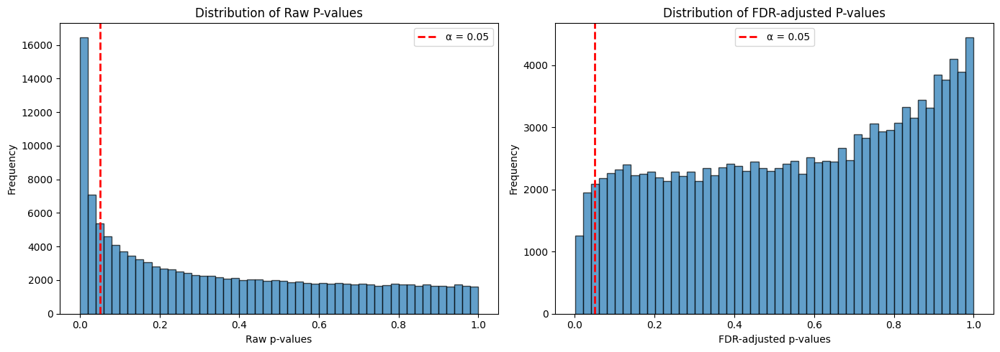

In [17]:
# Plot distribution of p-values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw p-values
axes[0].hist(p_values_matrix.flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Raw p-values')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Raw P-values')
axes[0].axvline(0.05, color='red', linestyle='--', label='α = 0.05', linewidth=2)
axes[0].legend()

# FDR-adjusted p-values
axes[1].hist(adjusted_p_values.flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('FDR-adjusted p-values')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of FDR-adjusted P-values')
axes[1].axvline(0.05, color='red', linestyle='--', label='α = 0.05', linewidth=2)
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
# Create significance-based masks at different alpha levels
alpha = 0.05

# Create binary masks
mask_raw = (p_values_matrix < alpha).astype(int)
mask_fdr = (adjusted_p_values < alpha).astype(int)

# Get t-values for significant units only
t_values_significant_raw = t_values_matrix.copy()
t_values_significant_raw[mask_raw == 0] = 0  # Zero out non-significant

t_values_significant_fdr = t_values_matrix.copy()
t_values_significant_fdr[mask_fdr == 0] = 0  # Zero out non-significant

print(f"Significance-based masks created at α = {alpha}:")
print(f"  Raw p-value mask: {mask_raw.sum():,} significant units")
print(f"  FDR-adjusted mask: {mask_fdr.sum():,} significant units")
print(f"\nMask shapes: {mask_raw.shape} (layers x units)")
print(f"T-values range for significant units (FDR):")
print(f"  Min: {t_values_matrix[mask_fdr == 1].min():.4f}")
print(f"  Max: {t_values_matrix[mask_fdr == 1].max():.4f}")
print(f"  Mean: {t_values_matrix[mask_fdr == 1].mean():.4f}")

Significance-based masks created at α = 0.05:
  Raw p-value mask: 26,404 significant units
  FDR-adjusted mask: 3,983 significant units

Mask shapes: (32, 4096) (layers x units)
T-values range for significant units (FDR):
  Min: -10.6184
  Max: 9.1466
  Mean: -0.0098


Save the significance-based masks and statistics for later use in interventions.

In [21]:
# Save masks and statistics
output_prefix = cache_path.replace("_raw_activations.npy", "")

# Save masks
os.makedirs("network_analysis_outputs", exist_ok=True)
np.save(f"network_analysis_outputs/{output_prefix}_mask_raw_p{alpha}.npy", mask_raw)
np.save(f"network_analysis_outputs/{output_prefix}_mask_fdr_p{alpha}.npy", mask_fdr)

# Save p-values matrices
np.save(f"network_analysis_outputs/{output_prefix}_pvalues_raw.npy", p_values_matrix)
np.save(f"network_analysis_outputs/{output_prefix}_pvalues_fdr.npy", adjusted_p_values)

# Save t-values matrix
np.save(f"network_analysis_outputs/{output_prefix}_tvalues.npy", t_values_matrix)
print("Saved files:")
print(f"  network_analysis_outputs/{output_prefix}_mask_raw_p{alpha}.npy")
print(f"  network_analysis_outputs/{output_prefix}_mask_fdr_p{alpha}.npy")
print(f"  network_analysis_outputs/{output_prefix}_pvalues_raw.npy")
print(f"  network_analysis_outputs/{output_prefix}_pvalues_fdr.npy")
print(f"  network_analysis_outputs/{output_prefix}_tvalues.npy")

Saved files:
  network_analysis_outputs/Llama-3.1-8B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_dataset=tom_chat=True_mask_raw_p0.05.npy
  network_analysis_outputs/Llama-3.1-8B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_dataset=tom_chat=True_mask_fdr_p0.05.npy
  network_analysis_outputs/Llama-3.1-8B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_dataset=tom_chat=True_pvalues_raw.npy
  network_analysis_outputs/Llama-3.1-8B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_dataset=tom_chat=True_pvalues_fdr.npy
  network_analysis_outputs/Llama-3.1-8B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_dataset=tom_chat=True_tvalues.npy


Mask comparison via visualisation

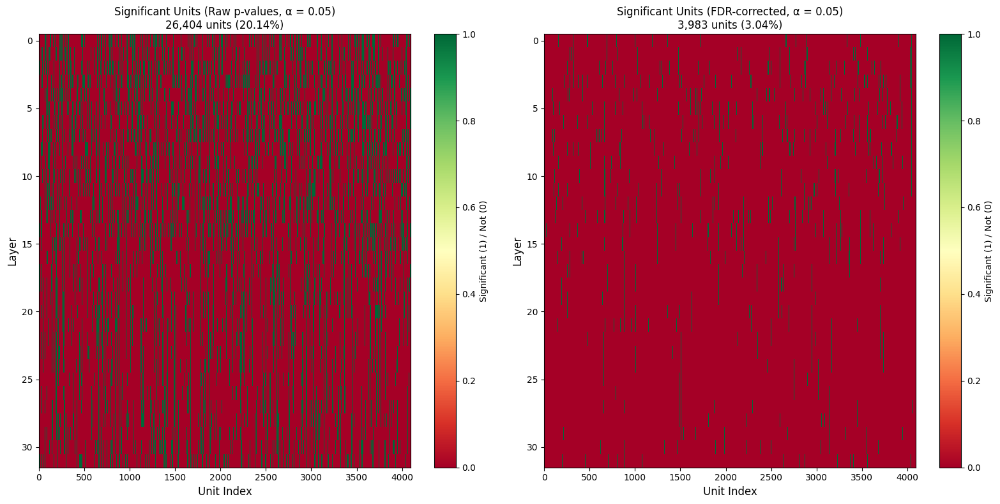

In [34]:
# Compare raw vs FDR-corrected masks
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Raw p-value mask
im1 = axes[0].imshow(mask_raw, aspect='auto', cmap='RdYlGn', interpolation='nearest')
axes[0].set_xlabel('Unit Index', fontsize=12)
axes[0].set_ylabel('Layer', fontsize=12)
axes[0].set_title(f'Significant Units (Raw p-values, α = {alpha})\n{mask_raw.sum():,} units ({(mask_raw.sum()/mask_raw.size)*100:.2f}%)', fontsize=12)
plt.colorbar(im1, ax=axes[0], label='Significant (1) / Not (0)')

# FDR-corrected mask
im2 = axes[1].imshow(mask_fdr, aspect='auto', cmap='RdYlGn', interpolation='nearest')
axes[1].set_xlabel('Unit Index', fontsize=12)
axes[1].set_ylabel('Layer', fontsize=12)
axes[1].set_title(f'Significant Units (FDR-corrected, α = {alpha})\n{mask_fdr.sum():,} units ({(mask_fdr.sum()/mask_fdr.size)*100:.2f}%)', fontsize=12)
plt.colorbar(im2, ax=axes[1], label='Significant (1) / Not (0)')

plt.tight_layout()
plt.show()

# Simple and conjunctive hypothesis testing based mask creation

We create eight different sets of masks for lesioning the models according to the following procedures (for the different localizer 'families' we have):

**Simple selection analyses**: 

1. strategic communication (paired)
    - *X*  = {strategic_communication_target}, *Y* = {strategic_communication_control}
    - *X* has 100 items, *Y* has 100 items
    - *T(u,X, Y )* calculated with a paired t-test and FDR correction
2. ToM suites from Saxe & Kanwisher (not paired)
    - *X*  = $\bigcup$ {false_beliefs, desires}, *Y* = $\bigcup$ {false_photographs, human_descriptions, non-human_descriptions, mechanistic_inference}
    - *X* has 200 items, *Y* has 400 items
    - *T(u,X, Y )* calculated with non paired t-test and FDR correction
3. deceptive communication (not paired)
    - *X*  = $\bigcup$ {deceitful, ironic}, *Y* = $\bigcup$ {literal, meaningless}
    - *X* has 200 items, *Y* has 200 items
    - *T(u,X, Y )* calculated with non paired t-test and FDR correction
4. moral intent (paired)
    - *X*  = {harmful-intent_bad-outcome}, *Y* = {control_general-situation-bad-outcome}
    - *X* has 100 items, *Y* has 100 items
    - *T(u,X, Y )* calculated with paired t-test and FDR correction
5. all scenarios combined
    - *X*  = $\bigcup$ {strategic_communication_target, false_beliefs, desires, deceitful, ironic, harmful-intent_bad-outcome}, *Y* = $\bigcup$ {strategic_communication_control, false_photographs, human_descriptions, non-human_descriptions, mechanistic_inference, literal, meaningless, control_general-situation-bad-outcome}
    - *X* has 600 items, *Y* has 800 items
    - *T(u,X, Y )* calculated with non paired t-test and FDR correction

**Conjunctive selection analyses**:

1. ToM suites from Saxe & Kanwisher:
    - for *X* in {false_beliefs, desires}:
        - for *Y* in {false_photographs, human_descriptions, non-human_descriptions, mechanistic_inference}:
            - we calculate *T(u,X, Y )*
    - for each unit *u*, we get 8 |t-values|, and select the smallest one among those 8 values (for target subnetwork selection). The idea is that we test whether a unit makes ALL pairwise comparisons significant. To test that, we need to check whether the ‘smallest effect’ is significant. If it is, the others will be, too (monotonicity of the t values wrt significance statistic).
    - for the random baseline subnetwork, we select units that have insignificant tests for all comparisons and the smallest t-value.
2. deceptive communication:
    - for *X* in {deceitful, ironic}:
        - for *Y* in {literal, meaningless}:
            - we calculate *T(u,X, Y )*
    - for each unit *u*, we get 4 |t-values|, and select the subnetworks as described above
3. conjunctive analysis for all scenarios combined
    - for *X* in {false_beliefs, desires, deceitful, ironic}:
        - for *Y* in {false_photographs, human_descriptions, non-human_descriptions, mechanistic_inference, literal, meaningless}:
            - we calculate *T(u,X, Y )*
    - for each unit *u*, we get 24 |t-values|, and select the subnetworks as described above


In [10]:
# define model directory, just in case
MODELS = [
    "Llama-3.1-8B"    ,           #0
"Llama-3.1-8B-Instruct"   ,   #1
"Llama-2-13b-hf"           ,  #2
"Llama-2-13b-chat-hf"       , #3
"Llama-3.1-70B"              ,#4
"Llama-3.3-70B-Instruct",     #5

"Falcon3-7B-Base"        ,        #6
"Falcon3-7B-Instruct"    ,        #7
"Falcon3-10B-Base"       ,        #8  
"Falcon3-10B-Instruct"   ,        #9

"gemma-2-9b-it"           ,       #10
"gemma-2-9b"        ,             #11
"gemma-2-27b-it"           ,      #12
"gemma-2-27b"              ,      #13

"Qwen2.5-7B" ,                      #14
"Qwen2.5-7B-Instruct",              #15
"Qwen2.5-32B"    ,                  #16
"Qwen2.5-32B-Instruct"  ,          #17
"Qwen2.5-72B"  ,                    #18
"Qwen2.5-72B-Instruct" ,            #19
]
datasets = {
    "tom": {
        "is_paired": False,
        "target": ["tom_d_synthetic", "tom_fb_synthetic"],
        "control": ["h_synthetic", "mechanical_inference", "nh_synthetic", "tom_fp_synthetic"]
    },
    "strategic_games": {
        "is_paired": True,
        "target": ["strategic_games_synthetic_eb"],
        "control": ["strategic_games_eo_synthetic_paired"]
    },
    "deceptive_communication": {
    "is_paired": False,
        "target": ["deceptive_iro_synthetic", "deceptive_dec_synthetic"],
        "control": ["deceptive_mls_synthetic", "deceptive_lit_synthetic"]
    },
    "moral_intent": {
    "is_paired": True,
        "target": ["moral_intent_tom_synthetic"],
        "control": ["moral_intent_control_synthetic"]
    }
}

In [11]:
# define simple testing, define conjunctive testing, distinguish between paired and unpaired t-tests
# write to a specific mask directory, which will contain the 8 masks
cache_path_positive = "../activations/cache_tom_fb_synthetic/gemma-2-9b_network=theory-of-mind_pooling=last-token_pretrained=True_dataset=deceptive_dec_synthetic_chat=True_without-answers=True_raw_activations.npy"
positive_data = np.load(cache_path_positive, allow_pickle=True).item()["positive"]

In [12]:
positive_data['model.layers.3']

array([[ 0.96205884, -0.20710421,  0.32989311, ..., -0.23961452,
        -0.58919632, -0.56842625],
       [ 1.04539061, -0.23279892,  0.31992328, ..., -0.26780033,
        -0.54256141, -0.48576695],
       [ 1.05158997, -0.21199048,  0.42057511, ..., -0.23513252,
        -0.48765326, -0.48642918],
       ...,
       [ 0.95716029, -0.24627247,  0.45843351, ..., -0.20571032,
        -0.46003973, -0.47543883],
       [ 1.03911626, -0.48247471,  0.54707038, ..., -0.26840329,
        -0.51072335, -0.57569408],
       [ 1.01438105, -0.15206999,  0.39581287, ..., -0.2131322 ,
        -0.61578077, -0.5167138 ]], shape=(100, 3584))

In [13]:
# define simple testing, define conjunctive testing, distinguish between paired and unpaired t-tests
# write to a specific mask directory, which will contain the 8 masks
cache_path_positive = "../activations/cache_tom_fb_synthetic/Llama-3.1-8B_network=theory-of-mind_pooling=last-token_pretrained=True_dataset=deceptive_lit_synthetic_chat=True_without-answers=True_raw_activations.npy"
positive_data = np.load(cache_path_positive, allow_pickle=True).item()["positive"]
positive_data['model.layers.3'].dtype

dtype('float64')

In [3]:
# both following functions are from localize.py
def is_topk(t_values, adjusted_p_values, k=1, alpha=0.05):
    _, rix = np.unique(-t_values, return_inverse=True)
    # maximum rank to consider
    max_rank = min(k, rix.max() + 1)
    #print("---- max rank ----", max_rank)
    # find p-values in rank order
    significant_ranks = []
    
    for r in range(max_rank):
        pvals_r = adjusted_p_values[rix == r]
        #print("pvals_r", pvals_r)
        if (pvals_r < alpha).all():
            significant_ranks.append(r)
        #else:
            #print("r", r)
            #print("---- breaking the topk loop -----")
            # break  # stop at first non-significant rank
    #print("r", r)
    # create mask only for still-significant ranks
    mask = np.isin(rix, significant_ranks).astype(int)
    mask = mask.reshape(t_values.shape)
    return mask
    
    
def is_bottomk(t_values, adjusted_p_values, k=1, alpha=0.05):
    _, rix = np.unique(t_values, return_inverse=True)
    # mask = np.where(rix < k, 1, 0).reshape(t_values.shape)
    max_rank = min(k, rix.max() + 1)
    # find p-values in rank order
    non_significant_ranks = []
    #print("max_rank", max_rank)
    for r in range(max_rank):
        pvals_r = adjusted_p_values[rix == r]
        print("pvals_r", pvals_r)
        if (pvals_r > alpha).all():
            non_significant_ranks.append(r)
        #else:
            #print("r", r)
            #print("---- breaking the topk loop -----")
            # break  # stop at first non-significant rank
    #print("r", r)
    #print(len(non_significant_ranks))
    # create mask only for still-significant ranks
    mask = np.isin(rix, non_significant_ranks).astype(int)
    #print("sum mask" , mask.sum())
    mask = mask.reshape(t_values.shape)
    return mask
    

## k-fold cross validation

In [18]:
"""
K-Fold Cross-Validation for Unit Selection

This module implements k-fold cross-validation for neural network unit localization.
Add these functions to your network_analytics.ipynb notebook after the is_topk/is_bottomk functions.
"""

import numpy as np
from scipy.stats import ttest_ind, ttest_rel, false_discovery_control
import os


def create_kfold_splits(n_samples, k=10, shuffle=True, random_state=42):
    """
    Create k-fold cross-validation splits.
    
    Args:
        n_samples: Number of samples to split
        k: Number of folds (default: 10)
        shuffle: Whether to shuffle indices before splitting
        random_state: Random seed for reproducibility
    
    Returns:
        List of k tuples (train_indices, test_indices)
    """
    indices = np.arange(n_samples)
    
    if shuffle:
        rng = np.random.RandomState(random_state)
        rng.shuffle(indices)
    
    fold_sizes = np.full(k, n_samples // k, dtype=int)
    fold_sizes[:n_samples % k] += 1
    
    current = 0
    splits = []
    for fold_size in fold_sizes:
        test_indices = indices[current:current + fold_size]
        train_indices = np.concatenate([indices[:current], indices[current + fold_size:]])
        splits.append((train_indices, test_indices))
        current += fold_size
    
    return splits


def compute_statistics_on_subset(representations, sample_indices, layer_names, is_paired=False):
    """
    Compute t-test statistics on a subset of samples.
    Uses the EXACT SAME LOGIC as run_simple_selection.
    
    Args:
        representations: Dict with 'positive' and 'negative' keys, each containing layer dicts
        sample_indices: Indices of samples to use
        layer_names: List of layer names
        is_paired: Whether to use paired t-test
    
    Returns:
        t_values_matrix: (num_layers, hidden_dim) - cleaned t-values with invalid set to 0
        p_values_matrix: (num_layers, hidden_dim) - cleaned raw p-values with invalid set to 1
    """
    num_layers = len(layer_names)
    hidden_dim = representations["positive"][layer_names[0]].shape[1]
    
    t_values_matrix = np.zeros((num_layers, hidden_dim))
    p_values_matrix = np.zeros((num_layers, hidden_dim))
    
    for layer_idx, layer_name in enumerate(layer_names):
        # Subset the activations and take absolute values
        positive_actv = np.abs(representations["positive"][layer_name][sample_indices])
        negative_actv = np.abs(representations["negative"][layer_name][sample_indices])
        
        # Perform t-test for each unit
        if is_paired:
            t_values_matrix[layer_idx], p_values_matrix[layer_idx] = ttest_rel(
                positive_actv, negative_actv, axis=0
            )
        else:
            t_values_matrix[layer_idx], p_values_matrix[layer_idx] = ttest_ind(
                positive_actv, negative_actv, axis=0, equal_var=False
            )
    
    # Clean invalid values (SAME LOGIC as run_simple_selection)
    p_values_flat = p_values_matrix.flatten()
    invalid = ~np.isfinite(p_values_flat) | (p_values_flat < 0) | (p_values_flat > 1)
    
    # Replace invalid p-values with 1.0 (maximally non-significant)
    p_values_flat_clean = p_values_flat.copy()
    p_values_flat_clean[invalid] = 1.0
    p_values_matrix = p_values_flat_clean.reshape(p_values_matrix.shape)
    
    # Set respective t-values to 0.0 (maximally non-significant test statistic)
    t_values_matrix_clean = t_values_matrix.copy()
    invalid_matrix = invalid.reshape(t_values_matrix.shape)
    t_values_matrix_clean[invalid_matrix] = 0.0
    
    return t_values_matrix_clean, p_values_matrix


def compute_conjunctive_statistics_on_subset(
    all_comparisons, sample_indices, layer_names, is_paired=False
):
    """
    Compute conjunctive t-test statistics on a subset of samples for multiple comparisons.
    Uses the EXACT SAME LOGIC as run_conjunctive_selection.
    
    Args:
        all_comparisons: List of dicts with 'positive' and 'negative' keys
        sample_indices: Indices of samples to use
        layer_names: List of layer names
        is_paired: Whether to use paired t-test
    
    Returns:
        t_values_min: (num_layers, hidden_dim) - minimum t-values across comparisons
        p_values_min: (num_layers, hidden_dim) - FDR-corrected p-values corresponding to minimum t
        all_t_values: (num_layers, hidden_dim, num_comparisons) - all t-values
        all_p_values: (num_layers, hidden_dim, num_comparisons) - all FDR-corrected p-values
    """
    num_comparisons = len(all_comparisons)
    num_layers = len(layer_names)
    hidden_dim = all_comparisons[0]["positive"][layer_names[0]].shape[1]
    
    # Initialize matrices to hold t-values and FDR-corrected p-values for each comparison
    t_values_matrix = np.zeros((num_layers, hidden_dim, num_comparisons))
    p_values_matrix = np.zeros((num_layers, hidden_dim, num_comparisons))
    
    for comparison_idx, comparison in enumerate(all_comparisons):
        for layer_idx, layer_name in enumerate(layer_names):
            # Subset and take absolute values
            positive_actv = np.abs(comparison["positive"][layer_name][sample_indices])
            negative_actv = np.abs(comparison["negative"][layer_name][sample_indices])
            
            # Perform t-test
            if is_paired:
                t_values_mat, p_values = ttest_rel(
                    positive_actv, negative_actv, axis=0
                )
            else:
                t_values_mat, p_values = ttest_ind(
                    positive_actv, negative_actv, axis=0, equal_var=False
                )
            
            # Clean invalid values (SAME LOGIC as run_conjunctive_selection)
            p_values_flat = p_values.flatten()
            invalid = ~np.isfinite(p_values_flat) | (p_values_flat < 0) | (p_values_flat > 1)
            
            # Replace invalid p-values with 1.0
            p_values_flat_clean = p_values_flat.copy()
            p_values_flat_clean[invalid] = 1.0
            
            # Set respective t-values to 0.0
            t_values_matrix_clean = t_values_mat.copy()
            invalid_matrix = invalid.reshape(t_values_mat.shape)
            t_values_matrix_clean[invalid_matrix] = 0.0
            
            # Apply FDR correction PER LAYER (SAME as run_conjunctive_selection)
            adjusted_p_values_flat = false_discovery_control(p_values_flat_clean)
            adjusted_p_values = adjusted_p_values_flat.reshape((hidden_dim))
            
            # Store results for this layer and comparison
            p_values_matrix[layer_idx, :, comparison_idx] = adjusted_p_values
            t_values_matrix[layer_idx, :, comparison_idx] = t_values_matrix_clean
    
    # Take minimum across comparisons (SAME as run_conjunctive_selection)
    t_values_min_indices = np.argmin(np.abs(t_values_matrix), axis=-1, keepdims=True)
    t_values_min = np.take_along_axis(
        t_values_matrix,
        t_values_min_indices,
        axis=-1
    ).squeeze(-1)
    p_values_min = np.take_along_axis(
        p_values_matrix,
        t_values_min_indices,
        axis=-1
    ).squeeze(-1)
    
    return t_values_min, p_values_min, t_values_matrix, p_values_matrix


def run_kfold_simple_selection(
    k=10,
    alpha=0.05,
    percentage=1,
    activations_dir="../activations/cache_tom_fb_synthetic/",
    models=None,  # Pass MODELS list
    datasets=None,  # Pass datasets dict
    results_out_dir=None,  # Will default to activations_dir/kfold_results/
    network="theory-of-mind",
    pooling="last-token",
    mask_type="theory-of-mind",
    random_state=42,
    overwrite=False,
    is_topk=None,  # Pass is_topk function
    is_bottomk=None,  # Pass is_bottomk function
):
    """
    K-fold cross-validation for simple unit selection.
    
    For each fold:
    - Localization set (k-1 folds): Run selection, get binary mask, t-values, p-values
    - Test set (1 fold): Compute t-values and p-values for evaluation
    
    Results are organized as: results_out_dir/suite_name/model_name/results.npy
    
    Args:
        k: Number of folds (default: 10)
        alpha: Significance level for FDR correction
        percentage: Percentage of units to select
        activations_dir: Directory with activation files
        models: List of model names
        datasets: Dict of dataset suites
        results_out_dir: Directory to save k-fold results (default: activations_dir/kfold_results/)
        network: Network type
        pooling: Pooling method
        mask_type: "theory-of-mind" or "random"
        random_state: Random seed for fold splitting
        overwrite: Whether to overwrite existing results
        is_topk: is_topk function reference
        is_bottomk: is_bottomk function reference
    """
    # Default results directory is a subdirectory of activations_dir
    if results_out_dir is None:
        results_out_dir = os.path.join(activations_dir, "kfold_results")
    
    os.makedirs(results_out_dir, exist_ok=True)
    
    activations_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_dataset={dataset}_chat=True_without-answers=True_raw_activations.npy"
    results_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_suite={suite_name}_k={k}_percentage={percentage}_p={alpha}_mask={mask_type}_kfold_results.npy"
    
    for model in models:
        print(f"\n{'='*80}")
        print(f"Model: {model}")
        print(f"{'='*80}")
        
        for suite_name, suite in datasets.items():
            print(f"\n--- Suite: {suite_name} ---")
            
            # Create suite/model directory structure
            suite_dir = os.path.join(results_out_dir, suite_name)
            model_dir = os.path.join(suite_dir, model)
            os.makedirs(model_dir, exist_ok=True)
            
            results_file_path = os.path.join(model_dir, results_file_template.format(
                model=model, network=network, pooling=pooling, suite_name=suite_name,
                k=k, percentage=percentage, alpha=alpha, mask_type=mask_type
            ))
            
            if os.path.exists(results_file_path) and not overwrite:
                print(f"Results already exist: {results_file_path}")
                continue
            
            # Load all activations for this suite
            representations = {}
            
            # Load target datasets
            for target_ds in suite["target"]:
                cache_path = activations_dir + activations_file_template.format(
                    model=model, network=network, pooling=pooling, dataset=target_ds
                )
                data = np.load(cache_path, allow_pickle=True).item()["positive"]
                
                if len(representations.keys()) == 0:
                    representations = {
                        "positive": {
                            layer_name: activations for layer_name, activations in data.items()
                        },
                        "negative": {},
                    }
                else:
                    for layer_name, activations in data.items():
                        representations["positive"][layer_name] = np.concatenate([
                            representations["positive"][layer_name],
                            activations
                        ], axis=0)
            
            # Load control datasets
            for control_ds in suite["control"]:
                cache_path = activations_dir + activations_file_template.format(
                    model=model, network=network, pooling=pooling, dataset=control_ds
                )
                data = np.load(cache_path, allow_pickle=True).item()["positive"]
                
                if len(representations["negative"].keys()) == 0:
                    representations["negative"] = {
                        layer_name: activations for layer_name, activations in data.items()
                    }
                else:
                    for layer_name, activations in data.items():
                        representations["negative"][layer_name] = np.concatenate([
                            representations["negative"][layer_name],
                            activations
                        ], axis=0)
            
            # Get layer names and dimensions
            layer_names = list(representations["positive"].keys())
            num_layers = len(layer_names)
            hidden_dim = representations["positive"][layer_names[0]].shape[1]
            n_samples = representations["positive"][layer_names[0]].shape[0]
            total_units = num_layers * hidden_dim
            
            print(f"Loaded {n_samples} samples, {num_layers} layers, {hidden_dim} units per layer")
            print(f"Total units: {total_units}")
            
            # Create k-fold splits
            splits = create_kfold_splits(n_samples, k=k, shuffle=True, random_state=random_state)
            
            # Store results for all folds
            all_folds_results = []
            
            for fold_idx, (loc_indices, test_indices) in enumerate(splits):
                print(f"\n--- Fold {fold_idx + 1}/{k} ---")
                print(f"Localization set: {len(loc_indices)} samples")
                print(f"Test set: {len(test_indices)} samples")
                
                # Compute statistics on localization set (k-1 folds)
                # Note: compute_statistics_on_subset now returns cleaned t and p values
                loc_t_values, loc_p_values_clean = compute_statistics_on_subset(
                    representations, loc_indices, layer_names, is_paired=suite.get("is_paired", False)
                )
                
                # Apply FDR correction on cleaned p-values (SAME as run_simple_selection)
                loc_p_values_fdr = false_discovery_control(
                    loc_p_values_clean.flatten(), method="bh"
                ).reshape(loc_p_values_clean.shape)
                
                # Create binary mask based on selection criteria
                if percentage is not None:
                    num_units = int((percentage / 100) * total_units)
                    print(f"  Selecting top {percentage}% = {num_units} units")
                    
                    abs_t_values = np.abs(loc_t_values)
                    
                    if mask_type == "random":
                        binary_mask = is_bottomk(abs_t_values, loc_p_values_fdr, num_units, alpha)
                    else:
                        binary_mask = is_topk(abs_t_values, loc_p_values_fdr, num_units, alpha)
                    
                    # Report localization set statistics
                    significant_units_fdr = (loc_p_values_fdr < alpha).sum()
                    percentage_fdr = (significant_units_fdr / total_units) * 100
                    print(f"  Localization set: {significant_units_fdr} significant units ({percentage_fdr:.2f}%)")
                    
                    selected_units = binary_mask.sum()
                    print(f"  Selected units: {selected_units}")
                
                # Compute statistics on test set (held-out fold)
                test_t_values, test_p_values = compute_statistics_on_subset(
                    representations, test_indices, layer_names, is_paired=suite.get("is_paired", False)
                )
                # add false_discovery_control to test_p_values as well
                test_p_values = false_discovery_control(
                    test_p_values.flatten(), method="bh"
                ).reshape(test_p_values.shape)
                
                # Store fold results
                fold_results = {
                    "fold_idx": fold_idx,
                    "loc_indices": loc_indices,
                    "test_indices": test_indices,
                    "loc_t_values": loc_t_values,
                    "loc_p_values_clean": loc_p_values_clean,
                    "loc_p_values_fdr": loc_p_values_fdr,
                    "binary_mask": binary_mask,
                    "test_t_values": test_t_values,
                    "test_p_values": test_p_values,
                }
                all_folds_results.append(fold_results)
            
            # Save all results
            results = {
                "model": model,
                "suite_name": suite_name,
                "k": k,
                "alpha": alpha,
                "percentage": percentage,
                "mask_type": mask_type,
                "random_state": random_state,
                "layer_names": layer_names,
                "num_layers": num_layers,
                "hidden_dim": hidden_dim,
                "n_samples": n_samples,
                "folds": all_folds_results,
            }
            
            np.save(results_file_path, results, allow_pickle=True)
            print(f"\n  Saved results to: {results_file_path}")


def run_kfold_conjunctive_selection(
    k=10,
    alpha=0.05,
    percentage=1,
    activations_dir="../activations/cache_tom_fb_synthetic/",
    models=None,
    datasets=None,
    results_out_dir=None,  # Will default to activations_dir/kfold_results/
    network="theory-of-mind",
    pooling="last-token",
    mask_type="theory-of-mind",
    random_state=42,
    overwrite=False,
    is_topk=None,
    is_bottomk=None,
):
    """
    K-fold cross-validation for conjunctive unit selection.
    
    For each fold:
    - Localization set (k-1 folds): Run conjunctive selection across all comparisons, 
      get binary mask, t-values, p-values
    - Test set (1 fold): Compute t-values and p-values for evaluation
    
    Results are organized as: results_out_dir/suite_name/model_name/results.npy
    
    Args:
        k: Number of folds (default: 10)
        alpha: Significance level for FDR correction
        percentage: Percentage of units to select
        activations_dir: Directory with activation files
        models: List of model names
        datasets: Dict of dataset suites
        results_out_dir: Directory to save k-fold results (default: activations_dir/kfold_results/)
        network: Network type
        pooling: Pooling method
        mask_type: "theory-of-mind" or "random"
        random_state: Random seed for fold splitting
        overwrite: Whether to overwrite existing results
        is_topk: is_topk function reference
        is_bottomk: is_bottomk function reference
    """
    # Default results directory is a subdirectory of activations_dir
    if results_out_dir is None:
        results_out_dir = os.path.join(activations_dir, "kfold_results")
    
    os.makedirs(results_out_dir, exist_ok=True)
    
    activations_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_dataset={dataset}_chat=True_without-answers=True_raw_activations.npy"
    results_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_suite={suite_name}_k={k}_percentage={percentage}_p={alpha}_mask={mask_type}_conjunctive_kfold_results.npy"
    
    for model in models:
        print(f"\n{'='*80}")
        print(f"Model: {model}")
        print(f"{'='*80}")
        
        for suite_name, suite in datasets.items():
            print(f"\n--- Suite: {suite_name} ---")
            
            # Create suite/model directory structure
            suite_dir = os.path.join(results_out_dir, suite_name)
            model_dir = os.path.join(suite_dir, model)
            os.makedirs(model_dir, exist_ok=True)
            
            results_file_path = os.path.join(model_dir, results_file_template.format(
                model=model, network=network, pooling=pooling, suite_name=suite_name,
                k=k, percentage=percentage, alpha=alpha, mask_type=mask_type
            ))
            
            if os.path.exists(results_file_path) and not overwrite:
                print(f"Results already exist: {results_file_path}")
                continue
            
            # Load activations for all target-control pairs
            all_comparisons = []
            
            for target_ds in suite["target"]:
                target_cache = activations_dir + activations_file_template.format(
                    model=model, network=network, pooling=pooling, dataset=target_ds
                )
                target_data = np.load(target_cache, allow_pickle=True).item()["positive"]
                
                for control_ds in suite["control"]:
                    control_cache = activations_dir + activations_file_template.format(
                        model=model, network=network, pooling=pooling, dataset=control_ds
                    )
                    control_data = np.load(control_cache, allow_pickle=True).item()["positive"]
                    
                    comparison = {
                        "target_name": target_ds,
                        "control_name": control_ds,
                        "positive": target_data,
                        "negative": control_data,
                    }
                    all_comparisons.append(comparison)
            
            # Get dimensions from first comparison
            layer_names = list(all_comparisons[0]["positive"].keys())
            num_layers = len(layer_names)
            hidden_dim = all_comparisons[0]["positive"][layer_names[0]].shape[1]
            n_samples = all_comparisons[0]["positive"][layer_names[0]].shape[0]
            total_units = num_layers * hidden_dim
            
            print(f"Loaded {len(all_comparisons)} comparisons")
            print(f"{n_samples} samples, {num_layers} layers, {hidden_dim} units per layer")
            print(f"Total units: {total_units}")
            
            # Create k-fold splits
            splits = create_kfold_splits(n_samples, k=k, shuffle=True, random_state=random_state)
            
            # Store results for all folds
            all_folds_results = []
            
            for fold_idx, (loc_indices, test_indices) in enumerate(splits):
                print(f"\n--- Fold {fold_idx + 1}/{k} ---")
                print(f"Localization set: {len(loc_indices)} samples")
                print(f"Test set: {len(test_indices)} samples")
                
                # Compute conjunctive statistics on localization set
                # This uses the EXACT SAME LOGIC as run_conjunctive_selection
                loc_t_values_min, loc_p_values_min, loc_all_t, loc_all_p = compute_conjunctive_statistics_on_subset(
                    all_comparisons, loc_indices, layer_names, is_paired=suite.get("is_paired", False)
                )
                
                # Create binary mask based on selection criteria
                if percentage is not None:
                    num_units = int((percentage / 100) * total_units)
                    print(f"  Selecting top {percentage}% = {num_units} units")
                    
                    abs_t_values = np.abs(loc_t_values_min)
                    
                    if mask_type == "random":
                        binary_mask = is_bottomk(abs_t_values, loc_p_values_min, num_units, alpha)
                        significant_units_fdr = (loc_p_values_min > alpha).sum()
                    else:
                        binary_mask = is_topk(abs_t_values, loc_p_values_min, num_units, alpha)
                        significant_units_fdr = (loc_p_values_min < alpha).sum()
                    
                    # Report localization set statistics
                    percentage_fdr = (significant_units_fdr / total_units) * 100
                    print(f"  Localization set: {significant_units_fdr} significant units ({percentage_fdr:.2f}%)")
                    
                    selected_units = binary_mask.sum()
                    print(f"  Selected units: {selected_units}")
                
                # Compute conjunctive statistics on test set
                test_t_values_min, test_p_values_min, test_all_t, test_all_p = compute_conjunctive_statistics_on_subset(
                    all_comparisons, test_indices, layer_names, is_paired=suite.get("is_paired", False)
                )
                
                # Store fold results
                fold_results = {
                    "fold_idx": fold_idx,
                    "loc_indices": loc_indices,
                    "test_indices": test_indices,
                    "loc_t_values": loc_t_values_min,
                    "loc_p_values": loc_p_values_min,
                    "binary_mask": binary_mask,
                    "test_t_values": test_t_values_min,
                    "test_p_values": test_p_values_min,
                    "all_loc_t_values": loc_all_t,
                    "all_loc_p_values": loc_all_p,
                    "all_test_t_values": test_all_t,
                    "all_test_p_values": test_all_p,
                }
                all_folds_results.append(fold_results)
            
            # Save all results
            results = {
                "model": model,
                "suite_name": suite_name,
                "k": k,
                "alpha": alpha,
                "percentage": percentage,
                "mask_type": mask_type,
                "random_state": random_state,
                "layer_names": layer_names,
                "num_layers": num_layers,
                "hidden_dim": hidden_dim,
                "n_samples": n_samples,
                "num_comparisons": len(all_comparisons),
                "folds": all_folds_results,
            }
            
            np.save(results_file_path, results, allow_pickle=True)
            print(f"\n  Saved results to: {results_file_path}")


def analyze_kfold_results(
    activations_dir,
    datasets,
    alpha=0.05,
    run_validation=True,
):
    """
    Analyze all k-fold validation results in the activations directory.
    Runs both standard analysis (mean |t|, replication) and validation analysis (target vs control).
    Saves results to activations_dir/paired/
    
    Args:
        activations_dir: Base directory containing kfold_results/ and raw activations
        datasets: Dict mapping suite names to target/control dataset configurations
        alpha: Significance threshold for analysis
        run_validation: Whether to run activation contrast validation (default: True)
    
    Returns:
        all_results: Dict mapping result file paths to their summary statistics
    """
    import glob
    
    # Create paired results directory
    paired_dir = os.path.join(activations_dir, "two_sided_validation_allUnits")
    os.makedirs(paired_dir, exist_ok=True)
    print(f"Results will be saved to: {paired_dir}\n")
    
    # Find all k-fold results files
    kfold_results_dir = os.path.join(activations_dir, "kfold_results")
    if not os.path.exists(kfold_results_dir):
        print(f"No kfold_results directory found at: {kfold_results_dir}")
        return {}
    
    results_files = glob.glob(os.path.join(kfold_results_dir, "**", "*.npy"), recursive=True)
    
    if len(results_files) == 0:
        print(f"No .npy files found in: {kfold_results_dir}")
        return {}
    
    print(f"Found {len(results_files)} k-fold results files")
    print("="*80)
    
    all_results = {}
    activations_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_dataset={dataset}_chat=True_without-answers=True_raw_activations.npy"
    
    for results_file_path in sorted(results_files):
        print(f"\n{'='*80}")
        print(f"Analyzing: {os.path.relpath(results_file_path, activations_dir)}")
        print(f"{'='*80}")
        
        # Load results file
        results = np.load(results_file_path, allow_pickle=True).item()
        
        k = results["k"]
        model = results["model"]
        suite_name = results["suite_name"]
        mask_type = results["mask_type"]
        layer_names = results["layer_names"]
        network = results.get("network", "theory-of-mind")
        pooling = results.get("pooling", "last-token")
        percentage = results.get("percentage", 1)
        
        # Check if suite exists in datasets
        if suite_name not in datasets:
            print(f"WARNING: Suite '{suite_name}' not found in datasets dict. Using conjunctive testing.")
            run_validation_for_this = False if suite_name == "all-localizer-conjunctive" else run_validation
        else:
            run_validation_for_this = run_validation
        
        print(f"Model: {model}")
        print(f"Suite: {suite_name}")
        print(f"Mask type: {mask_type}")
        print(f"Number of folds: {k}")
        print(f"Alpha: {alpha}")
        
        # Load validation representations if needed
        validation_reps = None
        if run_validation_for_this:
            if suite_name == "all-localizer":
                val_reps = np.load(f"../activations/cache_tom_fb_synthetic/all-localizers_activations/{model}_network={network}_pooling={pooling}_pretrained=True_suite={suite_name}-simple_raw-activations.npy", allow_pickle=True).item()
                is_paired = False
                # print("val_reps", val_reps)
            elif suite_name == "all-localizer-conjunctive":
                val_reps = np.load(f"../activations/cache_tom_fb_synthetic/all-localizers_activations/{model}_network={network}_pooling={pooling}_pretrained=True_suite={suite_name}_raw-activations.npy", allow_pickle=True)
                is_paired = False
                # print("val_reps len", len(val_reps))
            else:
                suite_config = datasets[suite_name]
                is_paired = suite_config.get("is_paired", False)
            
            print(f"\nLoading validation representations...")
            validation_reps = {"target": {}, "control": {}}

            if "all-localizer" in suite_name:
                validation_reps["target"] = val_reps["positive"]
                validation_reps["control"] = val_reps["negative"]
                print("All localizer target reps shape ", len(validation_reps["target"]))
            else:
                # Load target datasets
                for target_ds in suite_config["target"]:
                    cache_path = os.path.join(activations_dir, activations_file_template.format(
                        model=model, network=network, pooling=pooling, dataset=target_ds
                    ))
                    if not os.path.exists(cache_path):
                        print(f"  WARNING: Target file not found: {cache_path}")
                        continue
                    data = np.load(cache_path, allow_pickle=True).item()["positive"]
                    
                    if len(validation_reps["target"]) == 0:
                        validation_reps["target"] = {layer: actv.copy() for layer, actv in data.items()}
                    else:
                        for layer, actv in data.items():
                            validation_reps["target"][layer] = np.concatenate([
                                validation_reps["target"][layer], actv
                            ], axis=0)
                
                # Load control datasets
                for control_ds in suite_config["control"]:
                    cache_path = os.path.join(activations_dir, activations_file_template.format(
                        model=model, network=network, pooling=pooling, dataset=control_ds
                    ))
                    if not os.path.exists(cache_path):
                        print(f"  WARNING: Control file not found: {cache_path}")
                        continue
                    data = np.load(cache_path, allow_pickle=True).item()["positive"]
                    
                    if len(validation_reps["control"]) == 0:
                        validation_reps["control"] = {layer: actv.copy() for layer, actv in data.items()}
                    else:
                        for layer, actv in data.items():
                            validation_reps["control"][layer] = np.concatenate([
                                validation_reps["control"][layer], actv
                            ], axis=0)
            
            if len(validation_reps["target"]) > 0 and len(validation_reps["control"]) > 0:
                print(f"  Loaded validation data:")
                print(f"    Target: {validation_reps['target'][layer_names[0]].shape[0]} samples")
                print(f"    Control: {validation_reps['control'][layer_names[0]].shape[0]} samples")
            else:
                print(f"  WARNING: Could not load validation data. Skipping validation.")
                validation_reps = None
        
        # Analyze each fold
        metrics = []
        
        for fold in results["folds"]:
            fold_idx = fold["fold_idx"]
            binary_mask = fold["binary_mask"]
            test_t_values = fold["test_t_values"]
            test_p_values = fold["test_p_values"]
            test_indices = fold["test_indices"]
            
            # Standard metrics
            selected_test_t = test_t_values[binary_mask.astype(bool)]
            selected_test_p = test_p_values[binary_mask.astype(bool)]
            
            mean_t = np.mean(np.abs(selected_test_t))
            std_t = np.std(np.abs(selected_test_t))
            
            if mask_type == "random":
                significant_in_test = (selected_test_p > alpha).sum()
            else:    
                significant_in_test = (selected_test_p < alpha).sum()
            
            total_selected = binary_mask.sum()
            replication_rate = (significant_in_test / total_selected) * 100 if total_selected > 0 else 0
            
            fold_metrics = {
                "fold": fold_idx + 1,
                "mean_abs_t": mean_t,
                "std_abs_t": std_t,
                "significant_in_test": significant_in_test,
                "total_selected": total_selected,
                "replication_rate": replication_rate,
            }
            
            # Validation metrics
            if validation_reps is not None:
                target_activations = []
                control_activations = []
                
                for layer_idx, layer_name in enumerate(layer_names):
                    layer_mask = binary_mask[layer_idx].astype(bool)
                    
                    target_layer_actv = np.abs(validation_reps["target"][layer_name][test_indices])
                    target_layer_selected = target_layer_actv[:, layer_mask]
                    target_activations.append(target_layer_selected)
                    
                    control_layer_actv = np.abs(validation_reps["control"][layer_name][test_indices])
                    control_layer_selected = control_layer_actv[:, layer_mask]
                    control_activations.append(control_layer_selected)
                
                target_activations = np.concatenate(target_activations, axis=1)
                control_activations = np.concatenate(control_activations, axis=1)
                print("*** target_activations shape ***: ", target_activations.shape)
                print("*** control_activations shape ***: ", control_activations.shape)
                ### PT: why this mean? we might want to just do the calculation on the concatenations ####
                mean_target_per_item = target_activations.flatten() #target_activations.mean(axis=1)
                mean_control_per_item = control_activations.flatten() #control_activations.mean(axis=1)
                print("*** mean_target_per_item shape ***: ", mean_target_per_item.shape)
                print("*** mean_control_per_item shape ***: ", mean_control_per_item.shape)
                
                if is_paired:
                    val_t_stat, val_p_value = ttest_rel(
                        mean_target_per_item, mean_control_per_item, #alternative='greater'
                    )
                else:
                    val_t_stat, val_p_value = ttest_ind(
                        mean_target_per_item, mean_control_per_item, 
                        equal_var=False, #alternative='greater'
                    )
                
                pooled_std = np.sqrt((np.var(mean_target_per_item) + np.var(mean_control_per_item)) / 2)
                cohens_d = (mean_target_per_item.mean() - mean_control_per_item.mean()) / pooled_std if pooled_std > 0 else 0
                
                fold_metrics["validation"] = {
                    "t_stat": val_t_stat,
                    "p_value": val_p_value,
                    "cohens_d": cohens_d,
                    "mean_target": mean_target_per_item.mean(),
                    "mean_control": mean_control_per_item.mean(),
                    "is_significant": val_p_value < alpha,
                }
            
            metrics.append(fold_metrics)
            
            print(f"\nFold {fold_idx + 1}:")
            print(f"  Mean |t| on test set: {mean_t:.4f} ± {std_t:.4f}")
            print(f"  Significant in test (p < {alpha}): {significant_in_test}/{total_selected} ({replication_rate:.2f}%)")
            
            if validation_reps is not None:
                val = fold_metrics["validation"]
                print(f"  Validation (Target vs Control):")
                print(f"    Mean activation - Target: {val['mean_target']:.4f}, Control: {val['mean_control']:.4f}")
                print(f"    t-statistic: {val['t_stat']:.4f}, p-value: {val['p_value']:.6f}")
                print(f"    Cohen's d: {val['cohens_d']:.4f}")
                print(f"    Significant (p < {alpha}): {'Yes' if val['is_significant'] else 'No'}")
        
        # Aggregate statistics
        replication_rates = [m["replication_rate"] for m in metrics]
        mean_ts = [m["mean_abs_t"] for m in metrics]
        
        summary = {
            "model": model,
            "suite_name": suite_name,
            "mask_type": mask_type,
            "k": k,
            "alpha": alpha,
            "percentage": percentage,
            "mean_replication_rate": np.mean(replication_rates),
            "std_replication_rate": np.std(replication_rates),
            "mean_mean_abs_t": np.mean(mean_ts),
            "std_mean_abs_t": np.std(mean_ts),
            "min_replication_rate": np.min(replication_rates),
            "max_replication_rate": np.max(replication_rates),
        }
        
        if validation_reps is not None:
            val_t_stats = [m["validation"]["t_stat"] for m in metrics]
            val_p_values = [m["validation"]["p_value"] for m in metrics]
            val_cohens_ds = [m["validation"]["cohens_d"] for m in metrics]
            val_significant = [m["validation"]["is_significant"] for m in metrics]
            
            summary["validation_stats"] = {
                "mean_t_stat": np.mean(val_t_stats),
                "std_t_stat": np.std(val_t_stats),
                "mean_p_value": np.mean(val_p_values),
                "mean_cohens_d": np.mean(val_cohens_ds),
                "std_cohens_d": np.std(val_cohens_ds),
                "proportion_significant": np.mean(val_significant) * 100,
                "num_significant_folds": np.sum(val_significant),
            }
        
        print(f"\n{'='*60}")
        print(f"Summary Statistics Across Folds:")
        print(f"{'='*60}")
        print(f"Mean replication rate: {summary['mean_replication_rate']:.2f}% ± {summary['std_replication_rate']:.2f}%")
        print(f"Range: [{summary['min_replication_rate']:.2f}%, {summary['max_replication_rate']:.2f}%]")
        print(f"Mean |t| on test sets: {summary['mean_mean_abs_t']:.4f} ± {summary['std_mean_abs_t']:.4f}")
        
        if validation_reps is not None:
            val_stats = summary["validation_stats"]
            print(f"\nValidation Statistics (Target > Control):")
            print(f"  Mean t-statistic: {val_stats['mean_t_stat']:.4f} ± {val_stats['std_t_stat']:.4f}")
            print(f"  Mean p-value: {val_stats['mean_p_value']:.6f}")
            print(f"  Mean Cohen's d: {val_stats['mean_cohens_d']:.4f} ± {val_stats['std_cohens_d']:.4f}")
            print(f"  Significant folds: {val_stats['num_significant_folds']}/{k} ({val_stats['proportion_significant']:.1f}%)")
        
        print("="*60)
        
        # Save results to paired directory
        # Determine if conjunctive or simple from filename
        is_conjunctive = "conjunctive" in os.path.basename(results_file_path)
        selection_type = "conjunctive" if is_conjunctive else "simple"
        
        output_filename = f"{model}_suite={suite_name}_mask={mask_type}_selection={selection_type}_paired_analysis.npy"
        output_path = os.path.join(paired_dir, output_filename)
        
        output_data = {
            "summary": summary,
            "metrics": metrics,
            "source_file": results_file_path,
            # "validation_stats": val_stats
        }
        
        np.save(output_path, output_data, allow_pickle=True)
        print(f"\nSaved analysis to: {os.path.relpath(output_path, activations_dir)}")
        
        all_results[results_file_path] = output_data
    
    print(f"\n\n{'='*80}")
    print(f"COMPLETED ANALYSIS OF {len(all_results)} FILES")
    print(f"Results saved to: {paired_dir}")
    print(f"{'='*80}\n")
    
    return all_results

In [5]:
def run_kfold_all_localizer_simple(
    k=10,
    alpha=0.05,
    percentage=1,
    activations_dir="../activations/cache_tom_fb_synthetic/",
    models=None,
    datasets=None,  # Will use all datasets
    results_out_dir=None,
    network="theory-of-mind",
    pooling="last-token",
    mask_type="theory-of-mind",
    random_state=42,
    overwrite=False,
    is_topk=None,
    is_bottomk=None,
    only_dump_activations=False,
):
    """
    K-fold cross-validation for simple selection using ALL datasets combined.
    Unions all target datasets vs all control datasets across all suites.
    
    Args:
        Same as run_kfold_simple_selection
    """
    if results_out_dir is None:
        results_out_dir = os.path.join(activations_dir, "kfold_results")
    
    os.makedirs(results_out_dir, exist_ok=True)
    
    activations_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_dataset={dataset}_chat=True_without-answers=True_raw_activations.npy"
    results_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_suite={suite_name}_k={k}_percentage={percentage}_p={alpha}_mask={mask_type}_kfold_results.npy"
    
    for model in models:
        print(f"\n{'='*80}")
        print(f"Model: {model}")
        print(f"{'='*80}")
        
        suite_name = "all-localizer"
        print(f"\n--- Suite: {suite_name} (ALL datasets combined) ---")
        
        # Create suite/model directory structure
        suite_dir = os.path.join(results_out_dir, suite_name)
        model_dir = os.path.join(suite_dir, model)
        os.makedirs(model_dir, exist_ok=True)
        
        results_file_path = os.path.join(model_dir, results_file_template.format(
            model=model, network=network, pooling=pooling, suite_name=suite_name,
            k=k, percentage=percentage, alpha=alpha, mask_type=mask_type
        ))
        if not only_dump_activations:
            if os.path.exists(results_file_path) and not overwrite:
                print(f"Results already exist: {results_file_path}")
                continue
        
        # Collect all target and control datasets from all suites
        all_targets = []
        all_controls = []
        for suite_name_iter, suite in datasets.items():
            all_targets.extend(suite["target"])
            all_controls.extend(suite["control"])
        
        # Remove duplicates while preserving order
        all_targets = list(dict.fromkeys(all_targets))
        all_controls = list(dict.fromkeys(all_controls))
        
        print(f"Target datasets ({len(all_targets)}): {all_targets}")
        print(f"Control datasets ({len(all_controls)}): {all_controls}")
        
        # Load all activations
        representations = {}
        
        # Load all target datasets
        for target_ds in all_targets:
            cache_path = activations_dir + activations_file_template.format(
                model=model, network=network, pooling=pooling, dataset=target_ds
            )
            if not os.path.exists(cache_path):
                print(f"  WARNING: Target file not found: {cache_path}")
                continue
            data = np.load(cache_path, allow_pickle=True).item()["positive"]
            
            if len(representations.keys()) == 0:
                representations = {
                    "positive": {
                        layer_name: activations for layer_name, activations in data.items()
                    },
                    "negative": {},
                }
            else:
                for layer_name, activations in data.items():
                    representations["positive"][layer_name] = np.concatenate([
                        representations["positive"][layer_name],
                        activations
                    ], axis=0)
        
        # Load all control datasets
        for control_ds in all_controls:
            cache_path = activations_dir + activations_file_template.format(
                model=model, network=network, pooling=pooling, dataset=control_ds
            )
            if not os.path.exists(cache_path):
                print(f"  WARNING: Control file not found: {cache_path}")
                continue
            data = np.load(cache_path, allow_pickle=True).item()["positive"]
            
            if len(representations["negative"].keys()) == 0:
                representations["negative"] = {
                    layer_name: activations for layer_name, activations in data.items()
                }
            else:
                for layer_name, activations in data.items():
                    representations["negative"][layer_name] = np.concatenate([
                        representations["negative"][layer_name],
                        activations
                    ], axis=0)
        if only_dump_activations:
            np.save(f"../activations/cache_tom_fb_synthetic/all-localizers_activations/{model}_network={network}_pooling={pooling}_pretrained=True_suite={suite_name}-simple_raw-activations.npy", representations, allow_pickle=True)
            print("DUMPED ALL LOCALIZER REPRESENTATIONS")
            continue
            
        # Get layer names and dimensions
        layer_names = list(representations["positive"].keys())
        num_layers = len(layer_names)
        hidden_dim = representations["positive"][layer_names[0]].shape[1]
        n_samples = representations["positive"][layer_names[0]].shape[0]
        total_units = num_layers * hidden_dim
        
        print(f"Loaded {n_samples} samples, {num_layers} layers, {hidden_dim} units per layer")
        print(f"Total units: {total_units}")
        
        # Create k-fold splits
        splits = create_kfold_splits(n_samples, k=k, shuffle=True, random_state=random_state)
        
        # Store results for all folds
        all_folds_results = []
        
        for fold_idx, (loc_indices, test_indices) in enumerate(splits):
            print(f"\n--- Fold {fold_idx + 1}/{k} ---")
            print(f"Localization set: {len(loc_indices)} samples")
            print(f"Test set: {len(test_indices)} samples")
            
            # Compute statistics on localization set
            loc_t_values, loc_p_values_clean = compute_statistics_on_subset(
                representations, loc_indices, layer_names, is_paired=False  
            )
            
            # Apply FDR correction
            loc_p_values_fdr = false_discovery_control(
                loc_p_values_clean.flatten(), method="bh"
            ).reshape(loc_p_values_clean.shape)
            
            # Create binary mask
            if percentage is not None:
                num_units = int((percentage / 100) * total_units)
                print(f"  Selecting top {percentage}% = {num_units} units")
                
                abs_t_values = np.abs(loc_t_values)
                
                if mask_type == "random":
                    binary_mask = is_bottomk(abs_t_values, loc_p_values_fdr, num_units, alpha)
                else:
                    binary_mask = is_topk(abs_t_values, loc_p_values_fdr, num_units, alpha)
                
                significant_units_fdr = (loc_p_values_fdr < alpha).sum()
                percentage_fdr = (significant_units_fdr / total_units) * 100
                print(f"  Localization set: {significant_units_fdr} significant units ({percentage_fdr:.2f}%)")
                
                selected_units = binary_mask.sum()
                print(f"  Selected units: {selected_units}")
            
            # Compute statistics on test set
            test_t_values, test_p_values = compute_statistics_on_subset(
                representations, test_indices, layer_names, is_paired=False
            )
            test_p_values = false_discovery_control(
                test_p_values.flatten(), method="bh"
            ).reshape(test_p_values.shape)
            
            # Store fold results
            fold_results = {
                "fold_idx": fold_idx,
                "loc_indices": loc_indices,
                "test_indices": test_indices,
                "loc_t_values": loc_t_values,
                "loc_p_values_clean": loc_p_values_clean,
                "loc_p_values_fdr": loc_p_values_fdr,
                "binary_mask": binary_mask,
                "test_t_values": test_t_values,
                "test_p_values": test_p_values,
            }
            all_folds_results.append(fold_results)
        
        # Save all results
        results = {
            "model": model,
            "suite_name": "all-localizer",
            "k": k,
            "alpha": alpha,
            "percentage": percentage,
            "mask_type": mask_type,
            "random_state": random_state,
            "layer_names": layer_names,
            "num_layers": num_layers,
            "hidden_dim": hidden_dim,
            "n_samples": n_samples,
            "folds": all_folds_results,
            "all_targets": all_targets,
            "all_controls": all_controls,
        }
        
        np.save(results_file_path, results, allow_pickle=True)
        print(f"\n  Saved results to: {results_file_path}")


def run_kfold_all_localizer_conjunctive(
    k=10,
    alpha=0.05,
    percentage=1,
    activations_dir="../activations/cache_tom_fb_synthetic/",
    models=None,
    datasets=None,
    suites_to_combine=["tom", "deceptive_communication"], 
    results_out_dir=None,
    network="theory-of-mind",
    pooling="last-token",
    mask_type="theory-of-mind",
    random_state=42,
    overwrite=False,
    is_topk=None,
    is_bottomk=None,
    only_dump_activations=False,
):
    """
    K-fold cross-validation for conjunctive selection using combined suites.
    Default: Combines LatentBeliefs (tom) + CommunicativeIntent (deceptive_communication).
    
    Args:
        suites_to_combine: List of suite names to combine (default: ["tom", "deceptive_communication"])
        Other args: Same as run_kfold_conjunctive_selection
    """
    if results_out_dir is None:
        results_out_dir = os.path.join(activations_dir, "kfold_results")
    
    os.makedirs(results_out_dir, exist_ok=True)
    
    activations_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_dataset={dataset}_chat=True_without-answers=True_raw_activations.npy"
    results_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_suite={suite_name}_k={k}_percentage={percentage}_p={alpha}_mask={mask_type}_conjunctive_kfold_results.npy"
    
    for model in models:
        print(f"\n{'='*80}")
        print(f"Model: {model}")
        print(f"{'='*80}")
        
        suite_name = "all-localizer-conjunctive"
        print(f"\n--- Suite: {suite_name} (Combining: {suites_to_combine}) ---")
        
        # Create suite/model directory structure
        suite_dir = os.path.join(results_out_dir, suite_name)
        model_dir = os.path.join(suite_dir, model)
        os.makedirs(model_dir, exist_ok=True)
        
        results_file_path = os.path.join(model_dir, results_file_template.format(
            model=model, network=network, pooling=pooling, suite_name=suite_name,
            k=k, percentage=percentage, alpha=alpha, mask_type=mask_type
        ))
        if not only_dump_activations:
            if os.path.exists(results_file_path) and not overwrite:
                print(f"Results already exist: {results_file_path}")
                continue
        
        # Load activations for all target-control pairs from specified suites
        all_comparisons = []
        
        for suite_name_iter in suites_to_combine:
            if suite_name_iter not in datasets:
                print(f"  WARNING: Suite '{suite_name_iter}' not found in datasets")
                continue
            
            suite = datasets[suite_name_iter]
            print(f"  Loading suite: {suite_name_iter}")
            print(f"    Targets: {suite['target']}")
            print(f"    Controls: {suite['control']}")
            
            for target_ds in suite["target"]:
                target_cache = activations_dir + activations_file_template.format(
                    model=model, network=network, pooling=pooling, dataset=target_ds
                )
                if not os.path.exists(target_cache):
                    print(f"    WARNING: Target file not found: {target_cache}")
                    continue
                target_data = np.load(target_cache, allow_pickle=True).item()["positive"]
                
                for control_ds in suite["control"]:
                    control_cache = activations_dir + activations_file_template.format(
                        model=model, network=network, pooling=pooling, dataset=control_ds
                    )
                    if not os.path.exists(control_cache):
                        print(f"    WARNING: Control file not found: {control_cache}")
                        continue
                    control_data = np.load(control_cache, allow_pickle=True).item()["positive"]
                    
                    comparison = {
                        "target_name": target_ds,
                        "control_name": control_ds,
                        "suite": suite_name_iter,
                        "positive": target_data,
                        "negative": control_data,
                    }
                    all_comparisons.append(comparison)
        
        if len(all_comparisons) == 0:
            print(f"  ERROR: No comparisons loaded. Skipping model {model}")
            continue
        if only_dump_activations:
            np.save(f"../activations/cache_tom_fb_synthetic/all-localizers_activations/{model}_network={network}_pooling={pooling}_pretrained=True_suite={suite_name}_raw-activations.npy", all_comparisons, allow_pickle=True)
            print("DUMPED ALL LOCALIZER REPRESENTATIONS")
            continue
        # Get dimensions from first comparison
        layer_names = list(all_comparisons[0]["positive"].keys())
        num_layers = len(layer_names)
        hidden_dim = all_comparisons[0]["positive"][layer_names[0]].shape[1]
        n_samples = all_comparisons[0]["positive"][layer_names[0]].shape[0]
        total_units = num_layers * hidden_dim
        
        print(f"\nLoaded {len(all_comparisons)} comparisons")
        print(f"{n_samples} samples, {num_layers} layers, {hidden_dim} units per layer")
        print(f"Total units: {total_units}")
        
        # Create k-fold splits
        splits = create_kfold_splits(n_samples, k=k, shuffle=True, random_state=random_state)
        
        # Store results for all folds
        all_folds_results = []
        
        for fold_idx, (loc_indices, test_indices) in enumerate(splits):
            print(f"\n--- Fold {fold_idx + 1}/{k} ---")
            print(f"Localization set: {len(loc_indices)} samples")
            print(f"Test set: {len(test_indices)} samples")
            
            # Compute conjunctive statistics on localization set
            loc_t_values_min, loc_p_values_min, loc_all_t, loc_all_p = compute_conjunctive_statistics_on_subset(
                all_comparisons, loc_indices, layer_names, is_paired=False  # Always unpaired
            )
            
            # Create binary mask
            if percentage is not None:
                num_units = int((percentage / 100) * total_units)
                print(f"  Selecting top {percentage}% = {num_units} units")
                
                abs_t_values = np.abs(loc_t_values_min)
                
                if mask_type == "random":
                    binary_mask = is_bottomk(abs_t_values, loc_p_values_min, num_units, alpha)
                    significant_units_fdr = (loc_p_values_min > alpha).sum()
                else:
                    binary_mask = is_topk(abs_t_values, loc_p_values_min, num_units, alpha)
                    significant_units_fdr = (loc_p_values_min < alpha).sum()
                
                percentage_fdr = (significant_units_fdr / total_units) * 100
                print(f"  Localization set: {significant_units_fdr} significant units ({percentage_fdr:.2f}%)")
                
                selected_units = binary_mask.sum()
                print(f"  Selected units: {selected_units}")
            
            # Compute conjunctive statistics on test set
            test_t_values_min, test_p_values_min, test_all_t, test_all_p = compute_conjunctive_statistics_on_subset(
                all_comparisons, test_indices, layer_names, is_paired=False
            )
            
            # Store fold results
            fold_results = {
                "fold_idx": fold_idx,
                "loc_indices": loc_indices,
                "test_indices": test_indices,
                "loc_t_values": loc_t_values_min,
                "loc_p_values": loc_p_values_min,
                "binary_mask": binary_mask,
                "test_t_values": test_t_values_min,
                "test_p_values": test_p_values_min,
                "all_loc_t_values": loc_all_t,
                "all_loc_p_values": loc_all_p,
                "all_test_t_values": test_all_t,
                "all_test_p_values": test_all_p,
            }
            all_folds_results.append(fold_results)
        
        # Save all results
        results = {
            "model": model,
            "suite_name": "all-localizer-conjunctive",
            "suites_combined": suites_to_combine,
            "k": k,
            "alpha": alpha,
            "percentage": percentage,
            "mask_type": mask_type,
            "random_state": random_state,
            "layer_names": layer_names,
            "num_layers": num_layers,
            "hidden_dim": hidden_dim,
            "n_samples": n_samples,
            "num_comparisons": len(all_comparisons),
            "folds": all_folds_results,
        }
        
        np.save(results_file_path, results, allow_pickle=True)
        print(f"\n  Saved results to: {results_file_path}")

In [6]:
# Simple all-localizer: ALL datasets combined
run_kfold_all_localizer_simple(
    k=10,
    alpha=0.05,
    percentage=1,
    activations_dir="../activations/cache_tom_fb_synthetic/",
    models=MODELS,
    datasets=datasets,  
    mask_type="theory-of-mind",
    is_topk=is_topk,
    is_bottomk=is_bottomk,
    # only_dump_activations=True,
)

# Conjunctive all-localizer: LatentBeliefs + CommunicativeIntent
run_kfold_all_localizer_conjunctive(
    k=10,
    alpha=0.05,
    percentage=1,
    activations_dir="../activations/cache_tom_fb_synthetic/",
    models=MODELS,
    datasets=datasets,
    suites_to_combine=["tom", "deceptive_communication"],  
    mask_type="theory-of-mind",
    is_topk=is_topk,
    is_bottomk=is_bottomk,
    # only_dump_activations=True,
)


Model: Llama-3.1-8B

--- Suite: all-localizer-conjunctive (Combining: ['tom', 'deceptive_communication']) ---
  Loading suite: tom
    Targets: ['tom_d_synthetic', 'tom_fb_synthetic']
    Controls: ['h_synthetic', 'mechanical_inference', 'nh_synthetic', 'tom_fp_synthetic']
  Loading suite: deceptive_communication
    Targets: ['deceptive_iro_synthetic', 'deceptive_dec_synthetic']
    Controls: ['deceptive_mls_synthetic', 'deceptive_lit_synthetic']
DUMPED ALL LOCALIZER REPRESENTATIONS

Model: Llama-3.1-8B-Instruct

--- Suite: all-localizer-conjunctive (Combining: ['tom', 'deceptive_communication']) ---
  Loading suite: tom
    Targets: ['tom_d_synthetic', 'tom_fb_synthetic']
    Controls: ['h_synthetic', 'mechanical_inference', 'nh_synthetic', 'tom_fp_synthetic']
  Loading suite: deceptive_communication
    Targets: ['deceptive_iro_synthetic', 'deceptive_dec_synthetic']
    Controls: ['deceptive_mls_synthetic', 'deceptive_lit_synthetic']
DUMPED ALL LOCALIZER REPRESENTATIONS

Model: Lla

In [19]:
# Analyze all k-fold results in the directory with validation
all_results = analyze_kfold_results(
    activations_dir="../activations/cache_tom_fb_synthetic/",
    datasets=datasets,  # Your existing datasets dict
    alpha=0.05,
    run_validation=True
)

# Access results for a specific file
for file_path, data in all_results.items():
    summary = data['summary']
    print(f"\n{summary['model']} - {summary['suite_name']} ({summary['mask_type']}):")
    print(f"  Replication: {summary['mean_replication_rate']:.2f}%")
    if 'validation_stats' in summary:
        val = summary['validation_stats']
        print(f"  Validation: t={val['mean_t_stat']:.2f}, d={val['mean_cohens_d']:.2f}, {val['num_significant_folds']}/{summary['k']} folds sig")

# Or load a saved result later
# saved_result = np.load("../activations/cache_tom_fb_synthetic/paired/Llama-3.1-8B_suite=tom_mask=theory-of-mind_selection=simple_paired_analysis.npy", allow_pickle=True).item()
# print(saved_result['summary'])

Results will be saved to: ../activations/cache_tom_fb_synthetic/two_sided_validation_allUnits

Found 200 k-fold results files

Analyzing: kfold_results/all-localizer-conjunctive/Falcon3-10B-Base/Falcon3-10B-Base_network=theory-of-mind_pooling=last-token_pretrained=True_suite=all-localizer-conjunctive_k=10_percentage=1_p=0.05_mask=theory-of-mind_conjunctive_kfold_results.npy
Model: Falcon3-10B-Base
Suite: all-localizer-conjunctive
Mask type: theory-of-mind
Number of folds: 10
Alpha: 0.05

Fold 1:
  Mean |t| on test set: 0.4063 ± 0.4145
  Significant in test (p < 0.05): 0/462 (0.00%)

Fold 2:
  Mean |t| on test set: 0.4107 ± 0.4137
  Significant in test (p < 0.05): 0/434 (0.00%)

Fold 3:
  Mean |t| on test set: 0.4339 ± 0.4479
  Significant in test (p < 0.05): 0/436 (0.00%)

Fold 4:
  Mean |t| on test set: 0.3319 ± 0.3467
  Significant in test (p < 0.05): 0/475 (0.00%)

Fold 5:
  Mean |t| on test set: 0.3377 ± 0.3240
  Significant in test (p < 0.05): 0/461 (0.00%)

Fold 6:
  Mean |t| on 

KeyboardInterrupt: 

In [12]:
results_table = []
for file_path, data in all_results.items():
    summary = data['summary']
    
    print(f"\n{summary['model']} - {summary['suite_name']} ({summary['mask_type']}):")
    print(f"  Replication: {summary['mean_replication_rate']:.2f}%")
    res = {
        "is_conjunctive": True if "conjunctive" in file_path else False,
        "model": summary["model"],
        "suite_name": summary['suite_name'],
        "mask_type": summary['mask_type'],
        "mean_replication_rate": summary['mean_replication_rate'].item(),
        "num_significant_folds": "none",
        "mean_p_value": "none",
    }
    if 'validation_stats' in summary:
        val = summary['validation_stats']
        res["num_significant_folds"] = (val['num_significant_folds']/summary['k']).item()
        res["mean_p_value"] = val["mean_p_value"].item()
        print(f"  Validation: t={val['mean_t_stat']:.2f}, d={val['mean_cohens_d']:.2f}, {val['num_significant_folds']}/{summary['k']} folds sig")
    results_table.append(res)


Falcon3-10B-Base - all-localizer-conjunctive (theory-of-mind):
  Replication: 0.00%

Falcon3-10B-Instruct - all-localizer-conjunctive (theory-of-mind):
  Replication: 0.00%

Falcon3-7B-Base - all-localizer-conjunctive (theory-of-mind):
  Replication: 0.00%

Falcon3-7B-Instruct - all-localizer-conjunctive (theory-of-mind):
  Replication: 0.00%

Llama-2-13b-chat-hf - all-localizer-conjunctive (theory-of-mind):
  Replication: 0.00%

Llama-2-13b-hf - all-localizer-conjunctive (theory-of-mind):
  Replication: 0.00%

Llama-3.1-70B - all-localizer-conjunctive (theory-of-mind):
  Replication: 0.01%

Llama-3.1-8B-Instruct - all-localizer-conjunctive (theory-of-mind):
  Replication: 0.00%

Llama-3.1-8B - all-localizer-conjunctive (theory-of-mind):
  Replication: 0.00%

Llama-3.3-70B-Instruct - all-localizer-conjunctive (theory-of-mind):
  Replication: 0.03%

Qwen2.5-32B-Instruct - all-localizer-conjunctive (theory-of-mind):
  Replication: 0.01%

Qwen2.5-32B - all-localizer-conjunctive (theory-o

In [13]:
results_df = pd.DataFrame(results_table)
results_df

,is_conjunctive,model,suite_name,mask_type,mean_replication_rate,num_significant_folds,mean_p_value
0,True,Falcon3-10B-Base,all-localizer-conjunctive,theory-of-mind,0.000000,none,none
1,True,Falcon3-10B-Instruct,all-localizer-conjunctive,theory-of-mind,0.000000,none,none
2,True,Falcon3-7B-Base,all-localizer-conjunctive,theory-of-mind,0.000000,none,none
3,True,Falcon3-7B-Instruct,all-localizer-conjunctive,theory-of-mind,0.000000,none,none
4,True,Llama-2-13b-chat-hf,all-localizer-conjunctive,theory-of-mind,0.000000,none,none
...,...,...,...,...,...,...,...
195,False,gemma-2-27b,tom,theory-of-mind,87.824445,1.0,0.0
196,True,gemma-2-9b-it,tom,theory-of-mind,0.039867,0.6,0.158034
197,False,gemma-2-9b-it,tom,theory-of-mind,87.727575,1.0,0.0
198,True,gemma-2-9b,tom,theory-of-mind,0.119606,0.8,0.071433


In [14]:
results_df.value_counts(["model", "suite_name"])
results_df[(results_df["model"] == "Falcon3-10B-Base") & (results_df["suite_name"] == "deceptive_communication")]
results_df_deduped = results_df.drop_duplicates()
results_df_deduped#.value_counts(["model", "suite_name"])

,is_conjunctive,model,suite_name,mask_type,mean_replication_rate,num_significant_folds,mean_p_value
0,True,Falcon3-10B-Base,all-localizer-conjunctive,theory-of-mind,0.000000,none,none
1,True,Falcon3-10B-Instruct,all-localizer-conjunctive,theory-of-mind,0.000000,none,none
2,True,Falcon3-7B-Base,all-localizer-conjunctive,theory-of-mind,0.000000,none,none
3,True,Falcon3-7B-Instruct,all-localizer-conjunctive,theory-of-mind,0.000000,none,none
4,True,Llama-2-13b-chat-hf,all-localizer-conjunctive,theory-of-mind,0.000000,none,none
...,...,...,...,...,...,...,...
195,False,gemma-2-27b,tom,theory-of-mind,87.824445,1.0,0.0
196,True,gemma-2-9b-it,tom,theory-of-mind,0.039867,0.6,0.158034
197,False,gemma-2-9b-it,tom,theory-of-mind,87.727575,1.0,0.0
198,True,gemma-2-9b,tom,theory-of-mind,0.119606,0.8,0.071433


In [16]:
results_df_validated_subset = results_df[results_df["num_significant_folds"] != "none"]

In [17]:
results_df_validated_subset.groupby(["suite_name", "is_conjunctive"]).agg({"mean_replication_rate": "mean", "num_significant_folds": "mean", "mean_p_value": "mean"})
# results_df_validated_subset.groupby(["suite_name", "is_conjunctive"]).mean("num_significant_folds")

mean_replication_rate  \
suite_name              is_conjunctive                          
all-localizer           False                       94.655264   
deceptive_communication False                       97.739134   
                        True                        41.932405   
moral_intent            False                      100.000000   
                        True                       100.000000   
strategic_games         False                       99.997714   
                        True                        99.943341   
tom                     False                       88.330829   
                        True                         0.102168   

                                       num_significant_folds mean_p_value  
suite_name              is_conjunctive                                     
all-localizer           False                          0.935     0.019993  
deceptive_communication False                          0.875     0.058725  
                        True                           0.685     0.099087  
moral_intent            False                           0.95     0.020559  
                        True                            0.95     0.020559  
strategic_games         False                          0.965     0.006826  
                        True                           0.965     0.006826  
tom                     False                           0.88      0.03936  
                        True                           0.765     0.096496

In [18]:
# results_df.to_csv("tentative_generalization_results_two-sided_allUnits_wAllSimple.csv")

In [24]:
test_models = MODELS
run_kfold_simple_selection(
    k=10,
    models=test_models,
    datasets=datasets,
    alpha=0.05,
    percentage=1,
    mask_type="theory-of-mind",
    is_topk=is_topk,
    is_bottomk=is_bottomk,
    overwrite=False
)


Model: Llama-3.1-8B

--- Suite: tom ---
Loaded 200 samples, 32 layers, 4096 units per layer
Total units: 131072

--- Fold 1/10 ---
Localization set: 180 samples
Test set: 20 samples
  Selecting top 1% = 1310 units
  Localization set: 58863 significant units (44.91%)
  Selected units: 1310

--- Fold 2/10 ---
Localization set: 180 samples
Test set: 20 samples
  Selecting top 1% = 1310 units
  Localization set: 57964 significant units (44.22%)
  Selected units: 1310

--- Fold 3/10 ---
Localization set: 180 samples
Test set: 20 samples
  Selecting top 1% = 1310 units
  Localization set: 57985 significant units (44.24%)
  Selected units: 1310

--- Fold 4/10 ---
Localization set: 180 samples
Test set: 20 samples
  Selecting top 1% = 1310 units
  Localization set: 58150 significant units (44.36%)
  Selected units: 1310

--- Fold 5/10 ---
Localization set: 180 samples
Test set: 20 samples
  Selecting top 1% = 1310 units
  Localization set: 58501 significant units (44.63%)
  Selected units: 13

ValueError: `ps` must include only numbers between 0 and 1.

In [ ]:
run_kfold_conjunctive_selection(
    k=10,
    models=test_models,
    datasets=datasets,
    alpha=0.05,
    percentage=1,
    mask_type="theory-of-mind",
    is_topk=is_topk,
    is_bottomk=is_bottomk,
    overwrite=False
)

In [4]:
results_path = "../activations/cache_tom_fb_synthetic/kfold_results/Llama-3.1-8B_network=theory-of-mind_pooling=last-token_pretrained=True_suite=tom_k=5_percentage=1_p=0.05_mask=theory-of-mind_kfold_results.npy"
summary, metrics = analyze_kfold_results(results_path, alpha=0.05)
# print(summary)
# print(metrics)

In [5]:
import numpy as np
res_test = np.load(results_path)
res_test

FileNotFoundError: [Errno 2] No such file or directory: '../activations/cache_tom_fb_synthetic/kfold_results/Llama-3.1-8B_network=theory-of-mind_pooling=last-token_pretrained=True_suite=tom_k=5_percentage=1_p=0.05_mask=theory-of-mind_kfold_results.npy'

In [3]:
# analyze results
all_localizer_results = os.listdir("../activations/cache_tom_fb_synthetic/kfold_results/all-localizer/Qwen2.5-32B-Instruct")
all_localizer_results

['Qwen2.5-32B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_suite=all-localizer_k=10_percentage=1_p=0.05_mask=theory-of-mind_kfold_results.npy']

In [14]:
def compute_mask_precision_recall(
    masks_dir="../activations/masks/cache_tom_fb_synthetic/",
    models=None,
    suites=["tom", "deceptive_communication"],
    network="theory-of-mind",
    pooling="last-token",
    percentage=1,
    alpha=0.05,
    save_results=True,
    results_dir="../activations/f1stats/",
):
    """
    Compare simple vs conjunctive masks for specified suites across all models.
    
    Args:
        masks_dir: Directory containing the mask files
        models: List of model names to analyze
        suites: List of suite names to compare (default: ["tom", "deceptive_communication"])
        network: Network type
        pooling: Pooling method
        percentage: Percentage parameter used in mask creation
        alpha: Alpha parameter used in mask creation
        save_results: Whether to save results as CSV
        results_dir: Directory to save CSV results
    
    Returns:
        DataFrame with precision, recall, F1 scores for each model and suite
    """
    if models is None:
        models = MODELS
    
    # Create results directory if saving
    if save_results:
        os.makedirs(results_dir, exist_ok=True)
    
    mask_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_suite={suite}_percentage={percentage}_p={alpha}_mask={mask_type}_fdr.npy"
    
    results = []
    
    for model in models:
        print(f"Analyzing {model}...")
        
        for suite in suites:
            # Load simple mask
            simple_mask_path = os.path.join(
                masks_dir,
                mask_file_template.format(
                    model=model, network=network, pooling=pooling,
                    suite=suite, percentage=percentage, alpha=alpha,
                    mask_type="theory-of-mind"
                )
            )
            
            # Load conjunctive mask
            conjunctive_mask_path = os.path.join(
                masks_dir,
                mask_file_template.format(
                    model=model, network=network, pooling=pooling,
                    suite=suite, percentage=percentage, alpha=alpha,
                    mask_type="theory-of-mind-conjunctive"
                )
            )
            
            # Check if both files exist
            if not os.path.exists(simple_mask_path):
                print(f"  WARNING: Simple mask not found for {suite}")
                continue
            if not os.path.exists(conjunctive_mask_path):
                print(f"  WARNING: Conjunctive mask not found for {suite}")
                continue
            
            # Load masks
            simple_mask = np.load(simple_mask_path)
            conjunctive_mask = np.load(conjunctive_mask_path)
            
            # Flatten masks for comparison
            simple_flat = simple_mask.flatten().astype(bool)
            conjunctive_flat = conjunctive_mask.flatten().astype(bool)
            
            # Calculate metrics treating simple as ground truth
            true_positives = np.sum(simple_flat & conjunctive_flat)
            false_positives = np.sum(~simple_flat & conjunctive_flat)
            false_negatives = np.sum(simple_flat & ~conjunctive_flat)
            
            # Precision: of the units conjunctive selected, how many are in simple?
            precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
            
            # Recall: of the units simple selected, how many are in conjunctive?
            recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
            
            # F1 score
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            
            # Jaccard similarity (intersection over union)
            intersection = np.sum(simple_flat & conjunctive_flat)
            union = np.sum(simple_flat | conjunctive_flat)
            jaccard = intersection / union if union > 0 else 0
            
            results.append({
                "model": model,
                "suite": suite,
                "simple_units": int(np.sum(simple_flat)),
                "conjunctive_units": int(np.sum(conjunctive_flat)),
                "overlap_units": int(true_positives),
                "precision": precision,
                "recall": recall,
                "f1_score": f1,
                "jaccard_similarity": jaccard,
            })
            
            print(f"  {suite}: Simple={np.sum(simple_flat)}, Conjunctive={np.sum(conjunctive_flat)}, Overlap={true_positives}, Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")
    
    df_results = pd.DataFrame(results)
    
    # Calculate and print average F1 scores per suite
    if len(df_results) > 0:
        print("\n" + "="*60)
        print("AVERAGE F1 SCORES ACROSS MODELS:")
        print("="*60)
        for suite in suites:
            suite_data = df_results[df_results['suite'] == suite]
            if len(suite_data) > 0:
                avg_f1 = suite_data['f1_score'].mean()
                avg_jaccard = suite_data['jaccard_similarity'].mean()
                print(f"{suite:30s}: F1 = {avg_f1:.4f}, Jaccard = {avg_jaccard:.4f}")
        print("="*60 + "\n")
    
    # Save results to CSV
    if save_results and len(df_results) > 0:
        csv_filename = f"mask_comparison_simple_vs_conjunctive_percentage={percentage}_p={alpha}.csv"
        csv_path = os.path.join(results_dir, csv_filename)
        df_results.to_csv(csv_path, index=False)
        print(f"Results saved to: {csv_path}")
    
    return df_results

In [15]:
# Calculate precision/recall for tom and deceptive_communication
mask_comparison_results = compute_mask_precision_recall(
    masks_dir="../activations/masks/cache_tom_fb_synthetic/",
    models=MODELS,
    suites=["tom", "deceptive_communication"],
    save_results=True,
    results_dir="../activations/f1stats/"
)

# Display results
mask_comparison_results

Analyzing Llama-3.1-8B...
  tom: Simple=1310, Conjunctive=1310, Overlap=641, Precision=0.489, Recall=0.489, F1=0.489
  deceptive_communication: Simple=1310, Conjunctive=1310, Overlap=764, Precision=0.583, Recall=0.583, F1=0.583
Analyzing Llama-3.1-8B-Instruct...
  tom: Simple=1310, Conjunctive=1310, Overlap=692, Precision=0.528, Recall=0.528, F1=0.528
  deceptive_communication: Simple=1310, Conjunctive=1310, Overlap=921, Precision=0.703, Recall=0.703, F1=0.703
Analyzing Llama-2-13b-hf...
  tom: Simple=2048, Conjunctive=2048, Overlap=1000, Precision=0.488, Recall=0.488, F1=0.488
  deceptive_communication: Simple=2048, Conjunctive=2048, Overlap=1234, Precision=0.603, Recall=0.603, F1=0.603
Analyzing Llama-2-13b-chat-hf...
  tom: Simple=2048, Conjunctive=2048, Overlap=1019, Precision=0.498, Recall=0.498, F1=0.498
  deceptive_communication: Simple=2048, Conjunctive=2048, Overlap=1386, Precision=0.677, Recall=0.677, F1=0.677
Analyzing Llama-3.1-70B...
  tom: Simple=6553, Conjunctive=6553, O

,model,suite,simple_units,conjunctive_units,overlap_units,precision,recall,f1_score,jaccard_similarity
0,Llama-3.1-8B,tom,1310,1310,641,0.489313,0.489313,0.489313,0.323901
1,Llama-3.1-8B,deceptive_communication,1310,1310,764,0.583206,0.583206,0.583206,0.411638
2,Llama-3.1-8B-Instruct,tom,1310,1310,692,0.528244,0.528244,0.528244,0.358921
3,Llama-3.1-8B-Instruct,deceptive_communication,1310,1310,921,0.703053,0.703053,0.703053,0.542084
4,Llama-2-13b-hf,tom,2048,2048,1000,0.488281,0.488281,0.488281,0.322997
5,Llama-2-13b-hf,deceptive_communication,2048,2048,1234,0.602539,0.602539,0.602539,0.431167
6,Llama-2-13b-chat-hf,tom,2048,2048,1019,0.497559,0.497559,0.497559,0.331167
7,Llama-2-13b-chat-hf,deceptive_communication,2048,2048,1386,0.676758,0.676758,0.676758,0.511439
8,Llama-3.1-70B,tom,6553,6553,3272,0.499313,0.499313,0.499313,0.332723
9,Llama-3.1-70B,deceptive_communication,6553,6553,4623,0.705478,0.705478,0.705478,0.544972


In [11]:
# note: assumes separate files per dataset

def run_simple_selection(
    alpha=0.05, 
    percentage=1,
    activations_dir="../activations/cache_tom_fb_synthetic/", 
    models=MODELS, 
    datasets=datasets, 
    masks_out_dir="../cache_tom_fb_synthetic/",
    network="theory-of-mind",
    pooling="last-token",
    mask_type = "theory-of-mind",
    overwrite=False,
):
    activations_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_dataset={dataset}_chat=True_without-answers=True_raw_activations.npy"
    # construct name of mask with alpha level and percentage level
    mask_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_suite={suite_name}_percentage={percentage}_p={alpha}_mask={mask_type}_fdr.npy"
    for model in models:
        # run single suite analyses
        
        all_representations = {}
        for suite_name, suite in datasets.items():
            representations = {}
            print(suite["target"])
            for target_ds in suite["target"]:
                print("target ds ", target_ds)
                cache_path_positive = activations_dir + activations_file_template.format(model=model, network=network, pooling=pooling, dataset=target_ds)
                positive_data = np.load(cache_path_positive, allow_pickle=True).item()["positive"]
                
                if len(representations.keys()) == 0:
                    # print("init positive activations")
                    # representations["positive"] = positive_data
                    representations["positive"] = {
                        layer: positive_data[layer].copy()
                        for layer in positive_data
                    }

                    layer_names = list(representations["positive"].keys())
                    num_layers = len(layer_names)
                    hidden_dim = representations["positive"][layer_names[0]].shape[1]
                    print("-> shape of loaded activations positive_data ", positive_data[layer_names[0]].shape)
                # otherwise, append to the activations of a given layer additional samples for the union
                else:
                    # print("appending positive activations")
                    # print("positive representations shape before appending ", representations["positive"][layer_names[0]].shape)
                    # print("-> shape of loaded activations positive_data ", positive_data[layer_names[0]].shape)
                    for layer in layer_names:
                        representations["positive"][layer] = np.append(representations["positive"][layer], positive_data[layer].copy(), axis=0) 
                    # print("positive representations shape after appending ", representations["positive"][layer_names[0]].shape)
                # record all representations for conjunctive testing
                if len(all_representations.keys()) == 0:
                    all_representations["positive"] = {
                        layer: positive_data[layer].copy()
                        for layer in positive_data
                    }
                # otherwise, append to the activations of a given layer additional samples for the union
                else:
                    for layer in layer_names:
                        all_representations["positive"][layer] = np.append(all_representations["positive"][layer], positive_data[layer].copy(), axis=0) 
                print("---- positive representations shape at end of for loop step ", representations["positive"][layer_names[0]].shape)   
                # print("---- positive representations shape at end of for loop step ", representations["positive"][layer_names[1]].shape)   
            ###################################    
            for control_ds in suite["control"]:
                print("control ds", control_ds)
                cache_path_negative = activations_dir + activations_file_template.format(model=model, network=network, pooling=pooling, dataset=control_ds)
                negative_data = np.load(cache_path_negative, allow_pickle=True).item()["positive"]
                print("-> shape of loaded activations negative_data ", negative_data[layer_names[0]].shape)
                # If no activations have been loaded yet, initialize the dict
                if len(representations.keys()) == 1:
                    # print("init negative activations")
                    representations["negative"] = {
                        layer: negative_data[layer].copy()
                        for layer in negative_data
                    }
                # otherwise, append to the activations of a given layer additional samples for the union
                else:
                    # print("appending negative activations")
                    # print("negative representations shape before appending ", representations["negative"][layer_names[0]].shape)
                    for layer in layer_names:
                        representations["negative"][layer] = np.append(representations["negative"][layer], negative_data[layer].copy(), axis=0) 
                    # print("negative representations shape after appending ", representations["negative"][layer_names[0]].shape)
                
                if len(all_representations.keys()) == 1:
                    all_representations["negative"] = {
                        layer: negative_data[layer].copy()
                        for layer in negative_data
                    }
                # otherwise, append to the activations of a given layer additional samples for the union
                else:
                    for layer in layer_names:
                        all_representations["negative"][layer] = np.append(all_representations["negative"][layer], negative_data[layer].copy(), axis=0) 
                print("---- negative representations shape at end of for loop step ", representations["negative"][layer_names[0]].shape)                  
            #### calculate simple selection stats ####   
            if os.path.exists(masks_out_dir + mask_file_template.format(model=model, network=network, pooling=pooling, suite_name=suite_name, percentage=percentage, alpha=alpha, mask_type=mask_type)) and not overwrite:
                print("Mask already exists, continuing")
                continue
            p_values_matrix = np.zeros((num_layers, hidden_dim))
            t_values_matrix = np.zeros((num_layers, hidden_dim))
            
            # Perform t-tests for each layer and unit
            print(f"Running t-tests for {suite_name}...")
            for layer_idx, layer_name in enumerate(layer_names):
                # Take absolute values of activations (as done in localize.py)
                positive_actv = np.abs(representations["positive"][layer_name])
                negative_actv = np.abs(representations["negative"][layer_name])
                print("Shape of positive_actv at a single layer ", positive_actv.shape)
                print("Shape of negative_actv at a single layer ", negative_actv.shape)
                
                # Perform Welch's t-test (unequal variances) for each unit
                if suite["is_paired"]:
                    t_values_matrix[layer_idx], p_values_matrix[layer_idx] = ttest_rel(
                        positive_actv, negative_actv, axis=0
                    )
                else:
                    t_values_matrix[layer_idx], p_values_matrix[layer_idx] = ttest_ind(
                        positive_actv, negative_actv, axis=0, equal_var=False
                    )
            
            print(f"T-test completed for {num_layers} layers x {hidden_dim} units = {num_layers * hidden_dim:,} total units")
            total_units = num_layers * hidden_dim
            # Apply False Discovery Rate (FDR) correction using Benjamini-Hochberg procedure
            # Flatten all p-values across layers and units
            p_values_flat = p_values_matrix.flatten()     
            print("NaNs in p_values_flat ", np.isnan(p_values_flat).sum())
            # (based on errors in gemma-2):  Identify invalid entries
            invalid = ~np.isfinite(p_values_flat) | (p_values_flat < 0) | (p_values_flat > 1)
            
            print(f"Invalid p-values: {invalid.sum()} / {p_values_flat.size}")
            
            # Replace invalid p-values with 1 (maximally non-significant)
            p_values_flat_clean = p_values_flat.copy()
            p_values_flat_clean[invalid] = 1.0
            # set respective t-values to 0 (maximally non-significant test statistic)
            t_values_matrix_clean = t_values_matrix.copy()
            invalid_matrix = invalid.reshape(t_values_matrix.shape)
            print("invalid shape", invalid.shape)
            t_values_matrix_clean[invalid_matrix] = 0.0
            # Apply FDR correction
            # print(p_values_flat)
            print("NaNs in p_values_flat ", np.isnan(p_values_flat_clean).sum())
            print("<0 in p_values_flat ", (p_values_flat < 0).sum())
            print(">1 in p_values_flat ", (p_values_flat > 1).sum())
            
            adjusted_p_values_flat = false_discovery_control(p_values_flat_clean)
            # Reshape back to (layers x units)
            adjusted_p_values = adjusted_p_values_flat.reshape((len(layer_names), hidden_dim))        
            # Count units with FDR-adjusted p-values below alpha
            if mask_type == "random":
                significant_units_fdr = (adjusted_p_values > alpha).sum()
            else:
                significant_units_fdr = (adjusted_p_values < alpha).sum()
            percentage_fdr = (significant_units_fdr / total_units) * 100
            print(f"  WITH FDR correction:")
            print(f"   (non)-significant units: {significant_units_fdr:,} ({percentage_fdr:.2f}%)")

            # if a percentage is set, select top X% units with max or min t-values 
            if percentage is not None:
                # select units with biggest t-values
                num_units = int((percentage/100) * hidden_dim*len(layer_names))
                print(f"> Percentage: {percentage}% --> Num Units: {num_units}")
                abs_t_values_matrix = np.abs(t_values_matrix_clean)
                if mask_type == "theory-of-mind":
                    # left off here, these should catch all with same t value, check sorting
                    binary_mask = is_topk(abs_t_values_matrix, adjusted_p_values, k=num_units, alpha=alpha)
                    
                # select values with smallest t-values for random ablation
                elif mask_type == "random":
                    binary_mask = is_bottomk(abs_t_values_matrix, adjusted_p_values, k=num_units, alpha=alpha)
            mask_file_path = masks_out_dir + mask_file_template.format(model=model, network=network, pooling=pooling, suite_name=suite_name, percentage=percentage, alpha=alpha, mask_type=mask_type)
            np.save(mask_file_path, binary_mask)
            print(f"> {model} {network} mask cached to {mask_file_path}")
            
        
        ############ run analysis on union of all datasets ############
        
        p_values_matrix = np.zeros((num_layers, hidden_dim))
        t_values_matrix = np.zeros((num_layers, hidden_dim))
        total_units = num_layers * hidden_dim
        # Perform t-tests for each layer and unit
        print("Running conjunctive t-tests...")
        for layer_idx, layer_name in enumerate(layer_names):
            # Take absolute values of activations (as done in localize.py)
            positive_actv = np.abs(all_representations["positive"][layer_name])
            negative_actv = np.abs(all_representations["negative"][layer_name])
            # Perform Welch's t-test (unequal variances) for each unit
            
            t_values_matrix[layer_idx], p_values_matrix[layer_idx] = ttest_ind(
                positive_actv, negative_actv, axis=0, equal_var=False
            )
    
        print(f"T-test completed for {num_layers} layers x {hidden_dim} units = {num_layers * hidden_dim:,} total units")
        # Apply False Discovery Rate (FDR) correction using Benjamini-Hochberg procedure
        # Flatten all p-values across layers and units
        p_values_flat = p_values_matrix.flatten()    
        print("NaNs in p_values_flat ", np.isnan(p_values_flat).sum())
        # (based on errors in gemma-2):  Identify invalid entries
        invalid = ~np.isfinite(p_values_flat) | (p_values_flat < 0) | (p_values_flat > 1)
        
        print(f"Invalid p-values: {invalid.sum()} / {p_values_flat.size}")
        
        # Replace invalid p-values with 1 (maximally non-significant)
        p_values_flat_clean = p_values_flat.copy()
        p_values_flat_clean[invalid] = 1.0
        print("invalid shape", invalid.shape, invalid.sum(), t_values_matrix.shape)
        # set respective t-values to 0 (maximally non-significant test statistic)
        t_values_matrix_clean = t_values_matrix.copy()
        invalid_matrix = invalid.reshape(t_values_matrix.shape)
        t_values_matrix_clean[invalid_matrix] = 0.0
        # Apply FDR correction
        # print(p_values_flat)
        print("NaNs in p_values_flat ", np.isnan(p_values_flat_clean).sum())
        print("<0 in p_values_flat ", (p_values_flat < 0).sum())
        print(">1 in p_values_flat ", (p_values_flat > 1).sum())
        # Apply FDR correction
        adjusted_p_values_flat = false_discovery_control(p_values_flat_clean)
        # Reshape back to (layers x units)
        adjusted_p_values = adjusted_p_values_flat.reshape((len(layer_names), hidden_dim))        
        # Count units with FDR-adjusted p-values below alpha
        if mask_type == "random":
            significant_units_fdr = (adjusted_p_values > alpha).sum()
        else:
            significant_units_fdr = (adjusted_p_values < alpha).sum()
        percentage_fdr = (significant_units_fdr / total_units) * 100
        print(f"  WITH FDR correction:")
        print(f"   (non)-significant units: {significant_units_fdr:,} ({percentage_fdr:.2f}%)")

        # if a percentage is set, select top X% units with max or min t-values 
        if percentage is not None:
            # select units with biggest t-values
            num_units = int((percentage/100) * hidden_dim*len(layer_names))
            print(f"> Percentage: {percentage}% --> Num Units: {num_units}")
            abs_t_values_matrix = np.abs(t_values_matrix_clean)
            if mask_type == "theory-of-mind":
                # left off here, these should catch all with same t value, check sorting
                binary_mask = is_topk(abs_t_values_matrix, adjusted_p_values, k=num_units, alpha=alpha)
                
            # select values with smallest t-values for random ablation
            elif mask_type == "random":
                binary_mask = is_bottomk(abs_t_values_matrix, adjusted_p_values, k=num_units, alpha=alpha)
        mask_file_path = masks_out_dir + mask_file_template.format(model=model, network=network, pooling=pooling, suite_name="all-combined-selection", percentage=percentage, alpha=alpha, mask_type=mask_type)
        np.save(mask_file_path, binary_mask)
        print(f"> {model} {network} mask cached to {mask_file_path}")


In [3]:
gemma = [
    "gemma-2-9b-it"           ,       #10
"gemma-2-9b"        ,             #11
"gemma-2-27b-it"           ,      #12
"gemma-2-27b"              ,      #13
]
# run_simple_selection(models=gemma, overwrite=True)

In [13]:
run_simple_selection(models=gemma, overwrite=True, mask_type="random")

['tom_d_synthetic', 'tom_fb_synthetic']
target ds  tom_d_synthetic
-> shape of loaded activations positive_data  (100, 3584)
---- positive representations shape at end of for loop step  (100, 3584)
target ds  tom_fb_synthetic
---- positive representations shape at end of for loop step  (200, 3584)
control ds h_synthetic
-> shape of loaded activations negative_data  (100, 3584)
---- negative representations shape at end of for loop step  (100, 3584)
control ds mechanical_inference
-> shape of loaded activations negative_data  (100, 3584)
---- negative representations shape at end of for loop step  (200, 3584)
control ds nh_synthetic
-> shape of loaded activations negative_data  (100, 3584)
---- negative representations shape at end of for loop step  (300, 3584)
control ds tom_fp_synthetic
-> shape of loaded activations negative_data  (100, 3584)
---- negative representations shape at end of for loop step  (400, 3584)
Running t-tests for tom...
Shape of positive_actv at a single layer  (

In [5]:
run_simple_selection()

['tom_d_synthetic', 'tom_fb_synthetic']
target ds  tom_d_synthetic
-> shape of loaded activations positive_data  (100, 4096)
---- positive representations shape at end of for loop step  (100, 4096)
target ds  tom_fb_synthetic
---- positive representations shape at end of for loop step  (200, 4096)
control ds h_synthetic
-> shape of loaded activations negative_data  (100, 4096)
---- negative representations shape at end of for loop step  (100, 4096)
control ds mechanical_inference
-> shape of loaded activations negative_data  (100, 4096)
---- negative representations shape at end of for loop step  (200, 4096)
control ds nh_synthetic
-> shape of loaded activations negative_data  (100, 4096)
---- negative representations shape at end of for loop step  (300, 4096)
control ds tom_fp_synthetic
-> shape of loaded activations negative_data  (100, 4096)
---- negative representations shape at end of for loop step  (400, 4096)
Mask already exists, continuing
['strategic_games_synthetic_eb']
targe

In [5]:
run_simple_selection(mask_type="random")

['tom_d_synthetic', 'tom_fb_synthetic']
target ds  tom_d_synthetic
-> shape of loaded activations positive_data  (100, 4096)
---- positive representations shape at end of for loop step  (100, 4096)
target ds  tom_fb_synthetic
---- positive representations shape at end of for loop step  (200, 4096)
control ds h_synthetic
-> shape of loaded activations negative_data  (100, 4096)
---- negative representations shape at end of for loop step  (100, 4096)
control ds mechanical_inference
-> shape of loaded activations negative_data  (100, 4096)
---- negative representations shape at end of for loop step  (200, 4096)
control ds nh_synthetic
-> shape of loaded activations negative_data  (100, 4096)
---- negative representations shape at end of for loop step  (300, 4096)
control ds tom_fp_synthetic
-> shape of loaded activations negative_data  (100, 4096)
---- negative representations shape at end of for loop step  (400, 4096)
Mask already exists, continuing
['strategic_games_synthetic_eb']
targe

In [42]:
masks_out_dir = "../cache_tom_fb_synthetic/"
mask_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_suite=all-combined-selection_percentage={percentage}_p={alpha}_mask={mask_type}_fdr.npy"
    
for m in MODELS:
    for suite_name, s in datasets.items():
        mask_file_path = masks_out_dir + mask_file_template.format(model=m, network="theory-of-mind", pooling="last-token", suite_name=suite_name, percentage="1", alpha="0.05", mask_type="random")
        mask = np.load(mask_file_path)
        mask_sum = mask.sum()
        print(f"Model: {m}, suite name: {suite_name}, mask sum: {mask_sum} ")

Model: Llama-3.1-8B, suite name: tom, mask sum: 1310 
Model: Llama-3.1-8B, suite name: strategic_games, mask sum: 1310 
Model: Llama-3.1-8B, suite name: deceptive_communication, mask sum: 1310 
Model: Llama-3.1-8B, suite name: moral_intent, mask sum: 1310 
Model: Llama-3.1-8B-Instruct, suite name: tom, mask sum: 1310 
Model: Llama-3.1-8B-Instruct, suite name: strategic_games, mask sum: 1310 
Model: Llama-3.1-8B-Instruct, suite name: deceptive_communication, mask sum: 1310 
Model: Llama-3.1-8B-Instruct, suite name: moral_intent, mask sum: 1310 
Model: Llama-2-13b-hf, suite name: tom, mask sum: 2048 
Model: Llama-2-13b-hf, suite name: strategic_games, mask sum: 2048 
Model: Llama-2-13b-hf, suite name: deceptive_communication, mask sum: 2048 
Model: Llama-2-13b-hf, suite name: moral_intent, mask sum: 2048 
Model: Llama-2-13b-chat-hf, suite name: tom, mask sum: 2048 
Model: Llama-2-13b-chat-hf, suite name: strategic_games, mask sum: 2048 
Model: Llama-2-13b-chat-hf, suite name: deceptive_c

In [4]:
conjunctive_datasets = {
    "tom": {
        "is_paired": False,
        "target": ["tom_d_synthetic", "tom_fb_synthetic"],
        "control": ["h_synthetic", "mechanical_inference", "nh_synthetic", "tom_fp_synthetic"]
    },
    "deceptive_communication": {
    "is_paired": False,
        "target": ["deceptive_iro_synthetic", "deceptive_dec_synthetic"],
        "control": ["deceptive_mls_synthetic", "deceptive_lit_synthetic"]
    }
}

In [11]:
def run_conjunctive_selection(
    alpha=0.05, 
    percentage=1,
    activations_dir="../activations/cache_tom_fb_synthetic/", 
    models=MODELS, 
    datasets=conjunctive_datasets, 
    masks_out_dir="../cache_tom_fb_synthetic/",
    network="theory-of-mind",
    pooling="last-token",
    mask_type = "theory-of-mind",
    run_all_datasets = False,
    overwrite=False,
):
    # define t-value and p-value matrices which will hold the test results for each unit for each dataset pair; 
    # we will run min / max over that list for each single unit    
    activations_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_dataset={dataset}_chat=True_without-answers=True_raw_activations.npy"
    # construct name of mask with alpha level and percentage level
    mask_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_suite={suite_name}_percentage={percentage}_p={alpha}_mask={mask_type}-conjunctive_fdr.npy"
    for model in models:
        # run single suite analyses
        all_representations = {}
        for suite_name, suite in datasets.items():
            # print(suite["target"])
            representations = {}      
            num_comparisons = len(suite["target"]) * len(suite["control"])
            cache_path_positive = activations_dir + activations_file_template.format(model=model, network=network, pooling=pooling, dataset=suite["target"][0])
            _ = np.load(cache_path_positive, allow_pickle=True).item()["positive"]

            layer_names = list(_.keys())
            num_layers = len(layer_names)
            hidden_dim = _[layer_names[0]].shape[1]
            total_units = num_layers * hidden_dim
            p_values_matrix = np.zeros((num_layers, hidden_dim, num_comparisons))
            raw_p_values_matrix = np.zeros((num_layers, hidden_dim, num_comparisons))
            t_values_matrix = np.zeros((num_layers, hidden_dim, num_comparisons))
            comparison_idx = 0
            for target_ds in suite["target"]:
                print("target ds ", target_ds)
                cache_path_positive = activations_dir + activations_file_template.format(model=model, network=network, pooling=pooling, dataset=target_ds)
                positive_data = np.load(cache_path_positive, allow_pickle=True).item()["positive"]

                # layer_names = list(positive_data.keys())
                # num_layers = len(layer_names)
                # hidden_dim = positive_data[layer_names[0]].shape[1]
                    # print("-> shape of loaded activations positive_data ", positive_data[layer_names[0]].shape)
                # otherwise, append to the activations of a given layer additional samples for the union
                
                for control_ds in suite["control"]:
                    # print("control ds", control_ds)
                    cache_path_negative = activations_dir + activations_file_template.format(model=model, network=network, pooling=pooling, dataset=control_ds)
                    negative_data = np.load(cache_path_negative, allow_pickle=True).item()["positive"]
                             
                    #### calculate conjunctive selection stats ####                                                   
                    # Perform t-tests for each layer and unit
                    # print(f"Running t-tests for {suite_name}...")
                    for layer_idx, layer_name in enumerate(layer_names):
                        # Take absolute values of activations (as done in localize.py)
                        positive_actv = np.abs(positive_data[layer_name])
                        negative_actv = np.abs(negative_data[layer_name])
                        
                        # Perform Welch's t-test (unequal variances) for each unit
                        if suite["is_paired"]:
                            t_values_mat, p_values = ttest_rel(
                                positive_actv, negative_actv, axis=0
                            )
                        else:
                            t_values_mat, p_values = ttest_ind(
                                positive_actv, negative_actv, axis=0, equal_var=False
                            )
                        raw_p_values_matrix[layer_idx, :, comparison_idx] = p_values
                        p_values_flat = p_values.flatten()  
                        # (based on errors in gemma-2):  Identify invalid entries
                        invalid = ~np.isfinite(p_values_flat) | (p_values_flat < 0) | (p_values_flat > 1)
                        
                        print(f"Invalid p-values: {invalid.sum()} / {p_values_flat.size}")
                        
                        # Replace invalid p-values with 1 (maximally non-significant)
                        p_values_flat_clean = p_values_flat.copy()
                        p_values_flat_clean[invalid] = 1.0
                        print("invalid shape", invalid.shape, invalid.sum(), t_values_matrix.shape)
                        # set respective t-values to 0 (maximally non-significant test statistic)
                        t_values_matrix_clean = t_values_mat.copy()
                        invalid_matrix = invalid.reshape(t_values_mat.shape)
                        t_values_matrix_clean[invalid_matrix] = 0.0
                        # Apply FDR correction
                        adjusted_p_values_flat = false_discovery_control(p_values_flat_clean)
                        # Reshape back to (layers x units)
                        adjusted_p_values = adjusted_p_values_flat.reshape((hidden_dim))    
                        p_values_matrix[layer_idx, :, comparison_idx] = adjusted_p_values
                        t_values_matrix[layer_idx, :, comparison_idx] = t_values_matrix_clean
                        # print("t-values",  t_values_matrix[0][0])
                        # print("p-values ", p_values_matrix[1][1])
                    comparison_idx += 1
                
            t_values_min_indices = np.argmin(np.abs(t_values_matrix), axis=-1, keepdims=True)
            # print("t_values_min_indices", t_values_min_indices.shape, t_values_min_indices[0][0])
            t_values_min = np.take_along_axis(
                t_values_matrix,
                t_values_min_indices,
                axis=-1
            ).squeeze(-1)
            # print("t_values_min shape", t_values_min_indices.shape)
            p_values_min = np.take_along_axis(
                p_values_matrix,
                t_values_min_indices,
                axis=-1
            ).squeeze(-1)
            # print("p_values_min shape", p_values_min.shape)
            # print("t-values",  t_values_matrix[0][0])
            # print("adjusted p-values ", p_values_matrix[0][0])
            # print("raw p-values ", raw_p_values_matrix[0][0])
            # print("t-values min ",  t_values_min[0][0])
            # print("p-values min ", p_values_min[0][0])
            # if a percentage is set, select top X% units with max or min t-values 
            if percentage is not None:
                # select units with biggest t-values
                num_units = int((percentage/100) * hidden_dim*len(layer_names))
                # print(f"> Percentage: {percentage}% --> Num Units: {num_units}")
                abs_t_values_matrix = np.abs(t_values_min)
                if mask_type == "random":
                    significant_units_fdr = (p_values_min > alpha).sum()
                else:
                    significant_units_fdr = (p_values_min < alpha).sum()
                percentage_fdr = (significant_units_fdr / total_units) * 100
                print(f"  WITH FDR correction:")
                print(f"   (non)-significant units: {significant_units_fdr:,} ({percentage_fdr:.2f}%)")
        
                # significant_units_fdr = (p_values_min < alpha).sum()
                # percentage_fdr = (significant_units_fdr / total_units) * 100
                # print(f"  WITH FDR correction:")
                # print(f"    Significant units under the minimal statistic: {significant_units_fdr:,} ({percentage_fdr:.2f}%)")
                if mask_type == "theory-of-mind":
                    # left off here, these should catch all with same t value, check sorting
                    binary_mask = is_topk(abs_t_values_matrix, p_values_min, k=num_units, alpha=alpha)
                    
                # select values with smallest t-values for random ablation
                elif mask_type == "random":
                    binary_mask = is_bottomk(abs_t_values_matrix, p_values_min, k=num_units, alpha=alpha)
            if os.path.exists(masks_out_dir + mask_file_template.format(model=model, network=network, pooling=pooling, suite_name=suite_name, percentage=percentage, alpha=alpha, mask_type=mask_type)) and not overwrite:
                print("Mask already exists, continuing")
                continue
                
            mask_file_path = masks_out_dir + mask_file_template.format(model=model, network=network, pooling=pooling, suite_name=suite_name, percentage=percentage, alpha=alpha, mask_type=mask_type)
            np.save(mask_file_path, binary_mask)
            print(f"> {model} {network} mask cached to {mask_file_path}")
            
        
        ############ run analysis on union of all datasets ############
        if run_all_datasets:
            all_targets = [s for suite in datasets.values() for s in suite["target"]]
            all_controls = [s for suite in datasets.values() for s in suite["control"]]
            all_comparisons = len(all_targets) * len(all_controls)
            print("----- ALL COMPARISONS: -------- ", all_comparisons)
            # for suite_name, suite in datasets.items():
            #     print(suite["target"])
            suite = datasets[list(datasets.keys())[0]]
            cache_path_positive = activations_dir + activations_file_template.format(model=model, network=network, pooling=pooling, dataset=suite["target"][0])
            _ = np.load(cache_path_positive, allow_pickle=True).item()["positive"]

            layer_names = list(_.keys())
            num_layers = len(layer_names)
            hidden_dim = _[layer_names[0]].shape[1]
            total_units = num_layers * hidden_dim
            p_values_matrix = np.zeros((num_layers, hidden_dim, all_comparisons))
            raw_p_values_matrix = np.zeros((num_layers, hidden_dim, all_comparisons))
            t_values_matrix = np.zeros((num_layers, hidden_dim, all_comparisons))
            comparison_idx = 0
            for target_ds in all_targets:
                print("target ds ", target_ds)
                cache_path_positive = activations_dir + activations_file_template.format(model=model, network=network, pooling=pooling, dataset=target_ds)
                positive_data = np.load(cache_path_positive, allow_pickle=True).item()["positive"]

                # layer_names = list(positive_data.keys())
                # num_layers = len(layer_names)
                # hidden_dim = positive_data[layer_names[0]].shape[1]
                    # print("-> shape of loaded activations positive_data ", positive_data[layer_names[0]].shape)
                # otherwise, append to the activations of a given layer additional samples for the union
                
                for control_ds in all_controls:
                    print("control ds", control_ds)
                    cache_path_negative = activations_dir + activations_file_template.format(model=model, network=network, pooling=pooling, dataset=control_ds)
                    negative_data = np.load(cache_path_negative, allow_pickle=True).item()["positive"]
                             
                    #### calculate conjunctive selection stats ####                                                   
                    # Perform t-tests for each layer and unit
                    print(f"Running t-tests for {suite_name}...")
                    for layer_idx, layer_name in enumerate(layer_names):
                        # Take absolute values of activations (as done in localize.py)
                        positive_actv = np.abs(positive_data[layer_name])
                        negative_actv = np.abs(negative_data[layer_name])
                        
                        # Perform Welch's t-test (unequal variances) for each unit
                        if suite["is_paired"]:
                            t_values_mat, p_values = ttest_rel(
                                positive_actv, negative_actv, axis=0
                            )
                        else:
                            t_values_mat, p_values = ttest_ind(
                                positive_actv, negative_actv, axis=0, equal_var=False
                            )
                        raw_p_values_matrix[layer_idx, :, comparison_idx] = p_values
                        p_values_flat = p_values.flatten()    
                        # (based on errors in gemma-2):  Identify invalid entries
                        invalid = ~np.isfinite(p_values_flat) | (p_values_flat < 0) | (p_values_flat > 1)
                        
                        print(f"Invalid p-values: {invalid.sum()} / {p_values_flat.size}")
                        
                        # Replace invalid p-values with 1 (maximally non-significant)
                        p_values_flat_clean = p_values_flat.copy()
                        p_values_flat_clean[invalid] = 1.0
                        print("invalid shape", invalid.shape, invalid.sum(), t_values_matrix.shape)
                        # set respective t-values to 0 (maximally non-significant test statistic)
                        t_values_matrix_clean = t_values_mat.copy()
                        invalid_matrix = invalid.reshape(t_values_mat.shape)
                        t_values_matrix_clean[invalid_matrix] = 0.0
                        # Apply FDR correction
                        adjusted_p_values_flat = false_discovery_control(p_values_flat_clean)
                        # Reshape back to (layers x units)
                        adjusted_p_values = adjusted_p_values_flat.reshape((hidden_dim))    
                        p_values_matrix[layer_idx, :, comparison_idx] = adjusted_p_values
                        t_values_matrix[layer_idx, :, comparison_idx] = t_values_matrix_clean
                        # print("t-values",  t_values_matrix[0][0])
                        # print("p-values ", p_values_matrix[1][1])
                    comparison_idx += 1
                    print("--------- comparison_idx -----------", comparison_idx)
            # TODO: this is not equivalent, due to potential differences in the ordering of adjusted the p-values due to numerical differences
            # t_values_min = np.abs(t_values_matrix).min(axis=-1)
            # p_values_min = p_values_matrix.max(axis=-1
            #### LEFT OFF HERE #####
            t_values_min_indices = np.argmin(np.abs(t_values_matrix), axis=-1, keepdims=True)
            print("t_values_min_indices", t_values_min_indices.shape, t_values_min_indices[0][0])
            t_values_min = np.take_along_axis(
                t_values_matrix,
                t_values_min_indices,
                axis=-1
            ).squeeze(-1)
            print("t_values_min shape", t_values_min_indices.shape)
            p_values_min = np.take_along_axis(
                p_values_matrix,
                t_values_min_indices,
                axis=-1
            ).squeeze(-1)
            print("p_values_min shape", p_values_min.shape)
            print("t-values",  t_values_matrix[0][0])
            print("adjusted p-values ", p_values_matrix[0][0])
            print("raw p-values ", raw_p_values_matrix[0][0])
            print("t-values min ",  t_values_min[0][0])
            print("p-values min ", p_values_min[0][0])
            # if a percentage is set, select top X% units with max or min t-values 
            if percentage is not None:
                # select units with biggest t-values
                num_units = int((percentage/100) * hidden_dim*len(layer_names))
                print(f"> Percentage: {percentage}% --> Num Units: {num_units}")
                abs_t_values_matrix = np.abs(t_values_min)
                if mask_type == "random":
                    significant_units_fdr = (p_values_min > alpha).sum()
                else:
                    significant_units_fdr = (p_values_min < alpha).sum()
                percentage_fdr = (significant_units_fdr / total_units) * 100
                print(f"  WITH FDR correction:")
                print(f"    Significant units under the minimal statistic: {significant_units_fdr:,} ({percentage_fdr:.2f}%)")
                if mask_type == "theory-of-mind":
                    # left off here, these should catch all with same t value, check sorting
                    binary_mask = is_topk(abs_t_values_matrix, p_values_min, k=num_units, alpha=alpha)
                    
                # select values with smallest t-values for random ablation
                elif mask_type == "random":
                    binary_mask = is_bottomk(abs_t_values_matrix, p_values_min, k=num_units, alpha=alpha)
            
            mask_file_path = masks_out_dir + mask_file_template.format(model=model, network=network, pooling=pooling, suite_name="all-combined-selection", percentage=percentage, alpha=alpha, mask_type=mask_type)
            np.save(mask_file_path, binary_mask)
            print(f"> {model} {network} mask cached to {mask_file_path}")


In [12]:
run_conjunctive_selection(models=gemma, run_all_datasets=True, overwrite=True)

target ds  tom_d_synthetic
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8

In [13]:
run_conjunctive_selection(models=gemma, mask_type="random", run_all_datasets=True, overwrite=True)

target ds  tom_d_synthetic
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8)
Invalid p-values: 0 / 3584
invalid shape (3584,) 0 (42, 3584, 8

In [45]:
run_conjunctive_selection(run_all_datasets=True)

target ds  tom_d_synthetic
target ds  tom_fb_synthetic
  WITH FDR correction:
   (non)-significant units: 3,304 (2.52%)
---- max rank ---- 1310
pvals_r [1.51403228e-21]
pvals_r [1.75439144e-18]
pvals_r [4.44788533e-16]
pvals_r [4.9902596e-14]
pvals_r [1.84065677e-12]
pvals_r [3.44899281e-13]
pvals_r [5.34155863e-13]
pvals_r [1.24987288e-12]
pvals_r [4.90638389e-12]
pvals_r [2.48809209e-12]
pvals_r [3.97852687e-12]
pvals_r [3.98774416e-12]
pvals_r [1.49948121e-11]
pvals_r [9.97072897e-12]
pvals_r [5.39725181e-11]
pvals_r [1.01882184e-11]
pvals_r [1.64006516e-11]
pvals_r [5.33988818e-11]
pvals_r [3.10197761e-11]
pvals_r [7.35521987e-11]
pvals_r [5.63400775e-11]
pvals_r [1.44830408e-10]
pvals_r [2.43957466e-10]
pvals_r [3.47584695e-10]
pvals_r [5.09540952e-10]
pvals_r [2.81158477e-10]
pvals_r [3.24890683e-10]
pvals_r [1.31375681e-09]
pvals_r [7.02420552e-10]
pvals_r [1.84946545e-09]
pvals_r [7.12860347e-10]
pvals_r [1.02357532e-09]
pvals_r [8.21360556e-10]
pvals_r [1.96106407e-09]
pvals_r

In [6]:
run_conjunctive_selection(mask_type="random", run_all_datasets=True)

target ds  tom_d_synthetic
target ds  tom_fb_synthetic
  WITH FDR correction:
   (non)-significant units: 127,768 (97.48%)
max_rank 1310
pvals_r [1. 1. 1. 1. 1. 1. 1. 1. 1.]
pvals_r [0.99998483]
pvals_r [0.99996773]
pvals_r [0.99996606]
pvals_r [0.99995675]
pvals_r [0.99995594]
pvals_r [0.99995278]
pvals_r [0.99995213]
pvals_r [0.99994684]
pvals_r [0.99998483]
pvals_r [0.99993864]
pvals_r [0.9999365]
pvals_r [0.99993616]
pvals_r [0.99993143]
pvals_r [0.99992952]
pvals_r [0.99992307]
pvals_r [0.99992139]
pvals_r [0.99992086]
pvals_r [0.99991315]
pvals_r [0.99990412]
pvals_r [0.99989975]
pvals_r [0.99989813]
pvals_r [0.99989648]
pvals_r [0.99989813]
pvals_r [0.99989574]
pvals_r [0.99989522]
pvals_r [0.99989422]
pvals_r [0.99988265]
pvals_r [0.99988179]
pvals_r [0.99989813]
pvals_r [0.999875]
pvals_r [0.99986948]
pvals_r [0.99986341]
pvals_r [0.99986336]
pvals_r [0.9998619]
pvals_r [0.99985805]
pvals_r [0.99985575]
pvals_r [0.9998555]
pvals_r [0.99984244]
pvals_r [0.99989648]
pvals_r [0.9

In [ ]:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]

In [ ]:

mask_check = np.load("../cache_tom_fb_synthetic/Qwen2.5-72B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_suite=all-combined-selection_percentage=1_p=0.05_mask=theory-of-mind-conjunctive_fdr.npy")

In [14]:
mask_check.sum()

np.int64(1085)

In [49]:

mask_check = np.load("../cache_tom_fb_synthetic/Llama-3.1-8B_network=theory-of-mind_pooling=last-token_pretrained=True_suite=all-combined-selection_percentage=1_p=0.05_mask=theory-of-mind-conjunctive_fdr.npy")
mask_check.sum()

np.int64(196)

In [8]:
masks_out_dir = "../cache_tom_fb_synthetic/"
mask_file_template = "{model}_network={network}_pooling={pooling}_pretrained=True_suite={suite_name}_percentage={percentage}_p={alpha}_mask={mask_type}-conjunctive_fdr.npy"
    
for m in MODELS:
    for suite_name, s in conjunctive_datasets.items():
        mask_file_path = masks_out_dir + mask_file_template.format(model=m, network="theory-of-mind", pooling="last-token", suite_name=suite_name, percentage="1", alpha="0.05", mask_type="random")
        mask = np.load(mask_file_path)
        mask_sum = mask.sum()
        print(f"Model: {m}, suite name: {suite_name}, mask sum: {mask_sum} ")

Model: Llama-3.1-8B, suite name: tom, mask sum: 1318 
Model: Llama-3.1-8B, suite name: deceptive_communication, mask sum: 1389 
Model: Llama-3.1-8B-Instruct, suite name: tom, mask sum: 1316 
Model: Llama-3.1-8B-Instruct, suite name: deceptive_communication, mask sum: 1374 
Model: Llama-2-13b-hf, suite name: tom, mask sum: 2048 
Model: Llama-2-13b-hf, suite name: deceptive_communication, mask sum: 2060 
Model: Llama-2-13b-chat-hf, suite name: tom, mask sum: 2048 
Model: Llama-2-13b-chat-hf, suite name: deceptive_communication, mask sum: 2056 
Model: Llama-3.1-70B, suite name: tom, mask sum: 6583 
Model: Llama-3.1-70B, suite name: deceptive_communication, mask sum: 6871 
Model: Llama-3.3-70B-Instruct, suite name: tom, mask sum: 6608 
Model: Llama-3.3-70B-Instruct, suite name: deceptive_communication, mask sum: 6888 
Model: Falcon3-7B-Base, suite name: tom, mask sum: 862 
Model: Falcon3-7B-Base, suite name: deceptive_communication, mask sum: 896 
Model: Falcon3-7B-Instruct, suite name: to

### Applying the analyses to the activations retrieved with original dataset versions

In [17]:
MODELS_S = [
    "Llama-3.1-8B"    ,           #0
"Llama-3.1-8B-Instruct"   ,   #1

"Falcon3-7B-Base"        ,        #6
"Falcon3-7B-Instruct"    ,        #7
"Falcon3-10B-Base"       ,        #8  
"Falcon3-10B-Instruct"   ,        #9

"gemma-2-9b-it"           ,       #10
"gemma-2-9b"        ,             #11

"Qwen2.5-7B" ,                      #14
"Qwen2.5-7B-Instruct",              #15
]


datasets_original = {
    "tom": {
        "is_paired": False,
        "target": ["tom_d_original", "tom_fb_original"],
        "control": ["h_original", "nh_original", "tom_fp_original"] #  "mi_original",
    },
    "strategic_games": {
        "is_paired": False,
        "target": ["strategic_games_eb_original"],
        "control": ["strategic_games_eo_original"]
    },
    "deceptive_communication": {
    "is_paired": False,
        "target": ["deceptive_dec_original", "deceptive_iro_original"],
        "control": ["deceptive_lit_original", "deceptive_mls_original"]
    },
    "moral_intent": {
    "is_paired": False,
        "target": ["moral_intent_original"],
        "control": ["moral_intent_control_original"]
    }
}

In [18]:
run_simple_selection(
    alpha=0.05, 
    percentage=1,
    activations_dir="../activations/cache_original_stimuli/", 
    models=MODELS_S, 
    datasets=datasets_original, 
    masks_out_dir="../cache_original_stimuli/",
    network="theory-of-mind",
    pooling="last-token",
    mask_type = "theory-of-mind",
)

['tom_d_original', 'tom_fb_original']
target ds  tom_d_original
target ds  tom_fb_original
control ds h_original
control ds nh_original
control ds tom_fp_original
Running t-tests for tom...
T-test completed for 32 layers x 4096 units = 131,072 total units
  WITH FDR correction:
   (non)-significant units: 2,150 (1.64%)
> Percentage: 1% --> Num Units: 1310
---- breaking the topk loop -----
> Llama-3.1-8B theory-of-mind mask cached to ../cache_original_stimuli/Llama-3.1-8B_network=theory-of-mind_pooling=last-token_pretrained=True_suite=tom_percentage=1_p=0.05_mask=theory-of-mind_fdr.npy
['strategic_games_eb_original']
target ds  strategic_games_eb_original
control ds strategic_games_eo_original
Running t-tests for strategic_games...
T-test completed for 32 layers x 4096 units = 131,072 total units
  WITH FDR correction:
   (non)-significant units: 49,397 (37.69%)
> Percentage: 1% --> Num Units: 1310
> Llama-3.1-8B theory-of-mind mask cached to ../cache_original_stimuli/Llama-3.1-8B_netwo

In [19]:
run_simple_selection(
    alpha=0.05, 
    percentage=1,
    activations_dir="../activations/cache_original_stimuli/", 
    models=MODELS_S, 
    datasets=datasets_original, 
    masks_out_dir="../cache_original_stimuli/",
    network="theory-of-mind",
    pooling="last-token",
    mask_type = "random",
)

['tom_d_original', 'tom_fb_original']
target ds  tom_d_original
target ds  tom_fb_original
control ds h_original
control ds nh_original
control ds tom_fp_original
Running t-tests for tom...
T-test completed for 32 layers x 4096 units = 131,072 total units
  WITH FDR correction:
   (non)-significant units: 128,922 (98.36%)
> Percentage: 1% --> Num Units: 1310
> Llama-3.1-8B theory-of-mind mask cached to ../cache_original_stimuli/Llama-3.1-8B_network=theory-of-mind_pooling=last-token_pretrained=True_suite=tom_percentage=1_p=0.05_mask=random_fdr.npy
['strategic_games_eb_original']
target ds  strategic_games_eb_original
control ds strategic_games_eo_original
Running t-tests for strategic_games...
T-test completed for 32 layers x 4096 units = 131,072 total units
  WITH FDR correction:
   (non)-significant units: 81,675 (62.31%)
> Percentage: 1% --> Num Units: 1310
> Llama-3.1-8B theory-of-mind mask cached to ../cache_original_stimuli/Llama-3.1-8B_network=theory-of-mind_pooling=last-token_pr

In [23]:
conjunctive_datasets_original = {
    "tom": {
        "is_paired": False,
        "target": ["tom_d_original", "tom_fb_original"],
        "control": ["h_original", "nh_original", "tom_fp_original"] #  "mi_original",
    },
    "deceptive_communication": {
    "is_paired": False,
        "target": ["deceptive_dec_original", "deceptive_iro_original"],
        "control": ["deceptive_lit_original", "deceptive_mls_original"]
    }
}

In [26]:
run_conjunctive_selection(
    alpha=0.05, 
    percentage=1,
    activations_dir="../activations/cache_original_stimuli/", 
    models=MODELS_S, 
    datasets=conjunctive_datasets_original, 
    masks_out_dir="../cache_original_stimuli/",
    network="theory-of-mind",
    pooling="last-token",
    mask_type = "theory-of-mind",
    run_all_datasets = False,
)

['tom_d_original', 'tom_fb_original']
target ds  tom_d_original
control ds h_original
Running t-tests for tom...
control ds nh_original
Running t-tests for tom...
control ds tom_fp_original
Running t-tests for tom...
target ds  tom_fb_original
control ds h_original
Running t-tests for tom...
control ds nh_original
Running t-tests for tom...
control ds tom_fp_original
Running t-tests for tom...
t_values_min_indices (32, 4096, 1) [3]
t_values_min shape (32, 4096, 1)
p_values_min shape (32, 4096)
t-values [1.44371581 1.9632098  3.33632764 1.10828868 1.65624588 3.11738714]
adjusted p-values  [0.603433   0.44381625 0.26063377 0.9982984  0.98893603 0.97400194]
raw p-values  [0.17862877 0.07852151 0.01410796 0.29096123 0.12662238 0.01781187]
t-values min  1.108288684655435
p-values min  0.9982984035366347
> Percentage: 1% --> Num Units: 1310
  WITH FDR correction:
   (non)-significant units: 0 (0.00%)
---- breaking the topk loop -----
> Llama-3.1-8B theory-of-mind mask cached to ../cache_orig

In [27]:
run_conjunctive_selection(
    alpha=0.05, 
    percentage=1,
    activations_dir="../activations/cache_original_stimuli/", 
    models=MODELS_S, 
    datasets=conjunctive_datasets_original, 
    masks_out_dir="../cache_original_stimuli/",
    network="theory-of-mind",
    pooling="last-token",
    mask_type = "random",
    run_all_datasets = False,
)

['tom_d_original', 'tom_fb_original']
target ds  tom_d_original
control ds h_original
Running t-tests for tom...
control ds nh_original
Running t-tests for tom...
control ds tom_fp_original
Running t-tests for tom...
target ds  tom_fb_original
control ds h_original
Running t-tests for tom...
control ds nh_original
Running t-tests for tom...
control ds tom_fp_original
Running t-tests for tom...
t_values_min_indices (32, 4096, 1) [3]
t_values_min shape (32, 4096, 1)
p_values_min shape (32, 4096)
t-values [1.44371581 1.9632098  3.33632764 1.10828868 1.65624588 3.11738714]
adjusted p-values  [0.603433   0.44381625 0.26063377 0.9982984  0.98893603 0.97400194]
raw p-values  [0.17862877 0.07852151 0.01410796 0.29096123 0.12662238 0.01781187]
t-values min  1.108288684655435
p-values min  0.9982984035366347
> Percentage: 1% --> Num Units: 1310
  WITH FDR correction:
   (non)-significant units: 4,096 (3.12%)
> Llama-3.1-8B theory-of-mind mask cached to ../cache_original_stimuli/Llama-3.1-8B_netw